Loading CEPII Gravity (year=1988) in chunks…
  → 63504 bilateral rows for 1988.
  Origin-report coverage:      10181 / 63504
  Destination-report coverage: 11201 / 63504
  ★ Combined mirror coverage:  15187 / 63504

Loaded 7569 bilateral trade flows among top 100 nations.
Top 10 exporters: United States, Germany, Japan, France, United Kingdom, Italy, Canada, Netherlands, Belgium, Hong Kong
Top 10 ISO:      USA, DEU, JPN, FRA, GBR, ITA, CAN, NLD, BEL, HKG

Mean node strength c = 720.32 | Distance: [64-12741] km | r0 = 1502 km
WORLD COMMERCIAL NETWORK INFERENCE COMPLETE (0.8s)
• λ (Geopolitical weight)  : 0.5034 ± 0.0300
• 95% CI                   : [0.4446, 0.5622]
• r (Trade distance scale)  : 21232.2 km
• Geopolitical bloc (λ)    : 50.3%
• Gravity / proximity (1-λ): 49.7%


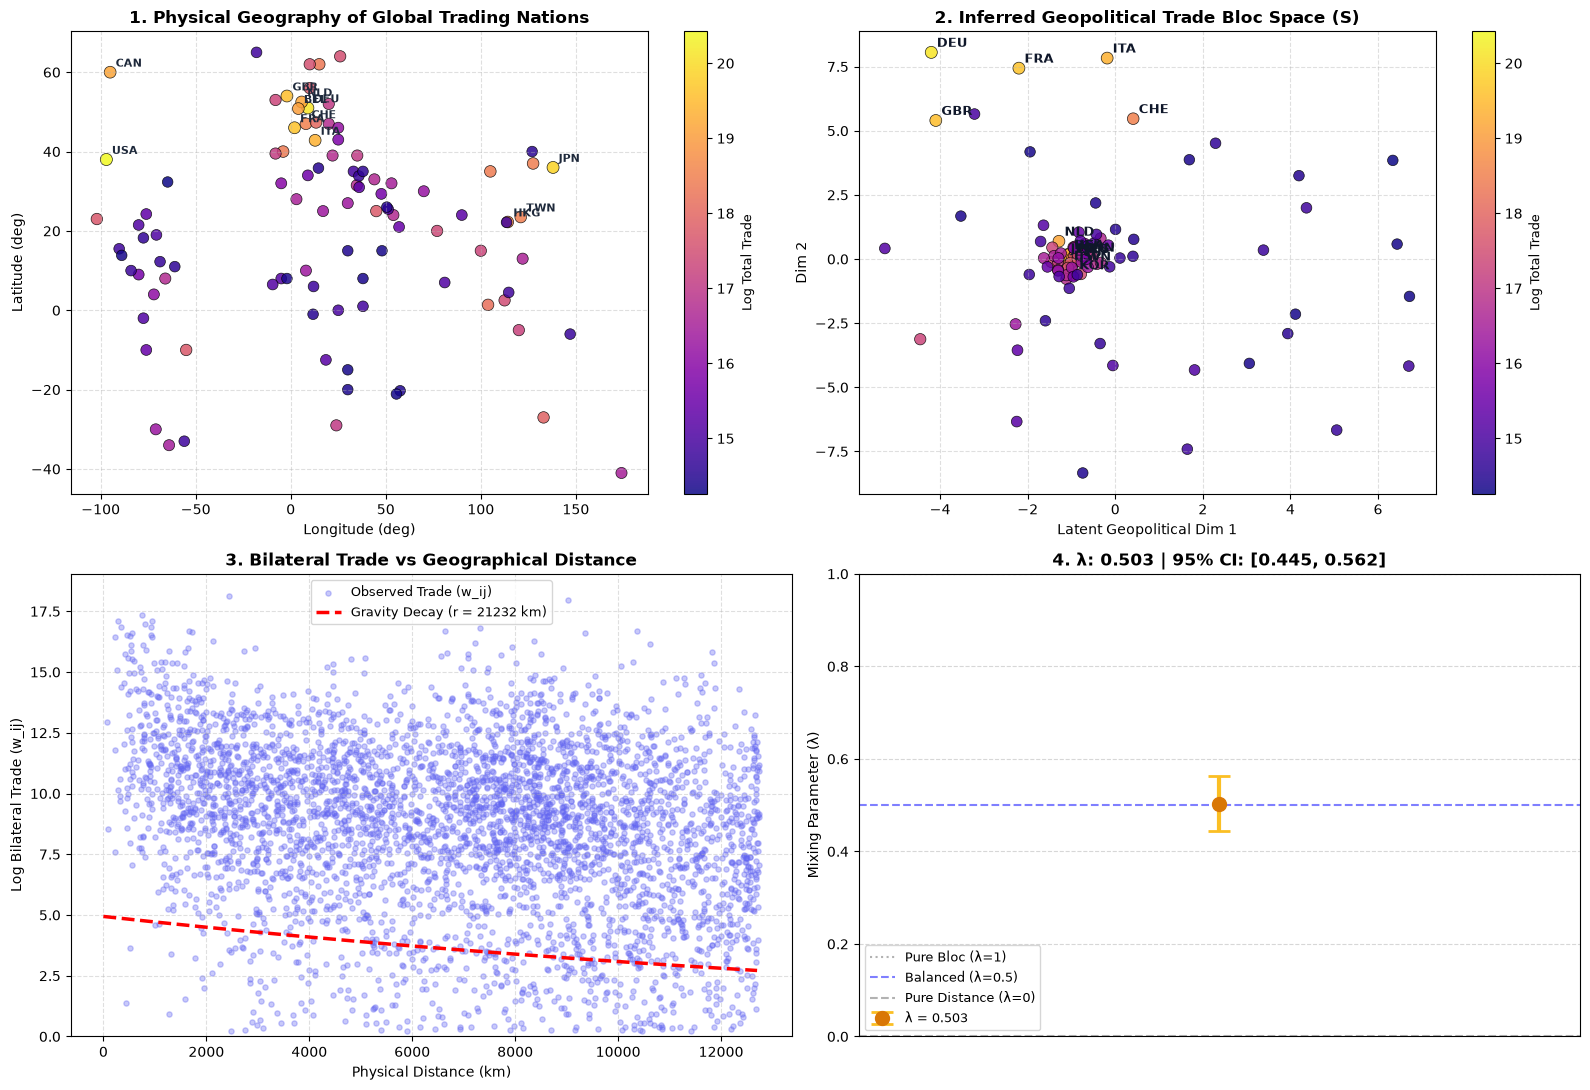

In [5]:
# ======================================================================
# WORLD COMMERCIAL NETWORK: INFERENCE OF GRAVITY VS GEOPOLITICS
# CEPII Gravity — Combined Mirror Trade Flows (Origin + Destination)
# ======================================================================

import time, torch, numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

device = torch.device("cpu")
torch.manual_seed(0); np.random.seed(0)

# ----------------------------------------------------------------------
# 1. Load CEPII Gravity with Mirror-Combined Trade Flows
# ----------------------------------------------------------------------
gravity_file = "data/World_commercial_network/Gravity_V202211.csv"
coords_file  = "data/World_commercial_network/countries_codes_and_coordinates.csv"
TARGET_YEAR  = 1988
N_NATIONS    = 100

# --- Coordinates lookup ---
df_c = pd.read_csv(coords_file)
df_c.columns = [c.strip().replace('"','') for c in df_c.columns]
for col in df_c.columns:
    df_c[col] = df_c[col].astype(str).str.strip().str.replace('"','')
df_c["lat"] = pd.to_numeric(df_c["Latitude (average)"], errors="coerce")
df_c["lon"] = pd.to_numeric(df_c["Longitude (average)"], errors="coerce")
df_c = df_c.dropna(subset=["Alpha-3 code","lat","lon"]).copy()
iso_to_lat  = dict(zip(df_c["Alpha-3 code"], df_c["lat"]))
iso_to_lon  = dict(zip(df_c["Alpha-3 code"], df_c["lon"]))
iso_to_name = dict(zip(df_c["Alpha-3 code"], df_c["Country"]))

# --- Read only needed columns in chunks ---
cols_to_use = ['year','iso3_o','iso3_d','tradeflow_comtrade_o','tradeflow_comtrade_d']

print(f"Loading CEPII Gravity (year={TARGET_YEAR}) in chunks…")
t0 = time.time()
chunks = []
for chunk in pd.read_csv(gravity_file, usecols=cols_to_use, chunksize=500_000):
    chunk = chunk[chunk['year'] == TARGET_YEAR]
    if not chunk.empty:
        chunks.append(chunk)
df_trade = pd.concat(chunks, ignore_index=True)
print(f"  → {len(df_trade)} bilateral rows for {TARGET_YEAR}.")

# ★ Combined mirror trade flows (Origin + Destination reports)
df_trade['val'] = df_trade['tradeflow_comtrade_o'].fillna(df_trade['tradeflow_comtrade_d'])

orig_only = df_trade['tradeflow_comtrade_o'].notna().sum()
dest_only = df_trade['tradeflow_comtrade_d'].notna().sum()
combined  = df_trade['val'].notna().sum()
print(f"  Origin-report coverage:      {orig_only} / {len(df_trade)}")
print(f"  Destination-report coverage: {dest_only} / {len(df_trade)}")
print(f"  ★ Combined mirror coverage:  {combined} / {len(df_trade)}")

# Filter: positive trade, distinct countries
df_trade = df_trade[
    (df_trade['val'] > 0) &
    (df_trade['iso3_o'] != df_trade['iso3_d'])
].copy()

# Total trade per country (as both exporter and importer)
trade_by_country = (
    df_trade.groupby('iso3_o')['val'].sum()
    .add(df_trade.groupby('iso3_d')['val'].sum(), fill_value=0)
)

# Select top-N nations with valid coordinates, ranked by total trade
all_countries = set(df_trade['iso3_o']).union(set(df_trade['iso3_d']))
valid = all_countries.intersection(set(iso_to_lat.keys()))
top_series = trade_by_country.loc[list(valid)].nlargest(N_NATIONS)
top_iso = set(top_series.index)
N_NATIONS = len(top_iso)

# Ranked DataFrame (descending by total trade volume)
df_top = pd.DataFrame({
    "iso":  top_series.index,
    "name": [iso_to_name.get(c, c) for c in top_series.index],
    "lat":  [iso_to_lat[c]  for c in top_series.index],
    "lon":  [iso_to_lon[c]  for c in top_series.index],
    "total_trade": top_series.values
}).reset_index(drop=True)

iso_to_idx = {iso: i for i, iso in enumerate(df_top["iso"])}

# Filter trade to top-N
trade_agg = df_trade[
    df_trade['iso3_o'].isin(top_iso) & df_trade['iso3_d'].isin(top_iso)
].copy()
trade_agg = trade_agg.groupby(['iso3_o','iso3_d'])['val'].sum().reset_index()
trade_agg.rename(columns={'iso3_o':'src','iso3_d':'dst'}, inplace=True)

print(f"\nLoaded {len(trade_agg)} bilateral trade flows among top {N_NATIONS} nations.")
print(f"Top 10 exporters: {', '.join(df_top['name'].head(10).values)}")
print(f"Top 10 ISO:      {', '.join(df_top['iso'].head(10).values)}")

# ----------------------------------------------------------------------
# 2. Build 3D Spherical Coordinates & Weighted Adjacency
# ----------------------------------------------------------------------
R_EARTH = 6371.0
lat_rad = np.radians(df_top["lat"].values)
lon_rad = np.radians(df_top["lon"].values)
x_geo = R_EARTH * np.cos(lat_rad) * np.cos(lon_rad)
y_geo = R_EARTH * np.cos(lat_rad) * np.sin(lon_rad)
z_geo = R_EARTH * np.sin(lat_rad)
X_3d  = np.column_stack([x_geo, y_geo, z_geo])

D_phys = cdist(X_3d, X_3d)
np.fill_diagonal(D_phys, 1e9)
iu, ju = np.triu_indices(N_NATIONS, k=1)

W_dir = np.zeros((N_NATIONS, N_NATIONS))
for _, row in trade_agg.iterrows():
    W_dir[iso_to_idx[row["src"]], iso_to_idx[row["dst"]]] += float(row["val"])

W_raw = 0.5 * (W_dir + W_dir.T)
W = np.log1p(W_raw)
c_target = float(W.sum(axis=1).mean())

r0     = float(2.0 * D_phys.min(axis=1).mean())
log_r0 = float(np.log(r0))
print(f"\nMean node strength c = {c_target:.2f} | "
      f"Distance: [{D_phys.min():.0f}-{D_phys[iu,ju].max():.0f}] km | r0 = {r0:.0f} km")

# ----------------------------------------------------------------------
# 3. Gauge-Invariant Profile Likelihood Inference
# ----------------------------------------------------------------------
t_inf = time.time()
SIGMA_GAUGE = 1.0; d_s = 2

D_phys_t = torch.tensor(D_phys, dtype=torch.float32, device=device)
W_obs_u  = torch.tensor(W[iu, ju], dtype=torch.float32, device=device)
iu_t     = torch.tensor(iu, dtype=torch.long, device=device)
ju_t     = torch.tensor(ju, dtype=torch.long, device=device)
eye_mask = 1.0 - torch.eye(N_NATIONS, device=device)

# SVD Residual Init
K_sp0 = np.exp(-D_phys / r0)
np.fill_diagonal(K_sp0, 0.0)
s_sp0 = K_sp0.sum(axis=1, keepdims=True) + 1e-12
W_sp0 = 0.5 * c_target * (K_sp0 / s_sp0 + K_sp0 / s_sp0.T)
R_init = np.maximum(0.0, W - W_sp0)

U, sv, _ = np.linalg.svd(R_init, full_matrices=False)
S_init = U[:, :d_s] * np.sqrt(sv[:d_s])
S_init = (S_init - S_init.mean(axis=0)) / (S_init.std() + 1e-9) * 3.0

logit_lam = torch.tensor(0.0, requires_grad=True, device=device)
log_r     = torch.tensor(log_r0, requires_grad=True, device=device)
S_param   = torch.tensor(S_init, requires_grad=True, device=device)

# Adam Warmup (50 steps)
adam_opt = torch.optim.Adam([
    {"params":[logit_lam],"lr":0.08},
    {"params":[log_r],    "lr":0.05},
    {"params":[S_param],  "lr":0.10}
])
for _ in range(50):
    adam_opt.zero_grad()
    lam = torch.sigmoid(logit_lam)
    r   = torch.exp(torch.clamp(log_r, log_r0-3, log_r0+3))
    K_sp = torch.exp(-D_phys_t / r) * eye_mask
    diff = S_param.unsqueeze(1) - S_param.unsqueeze(0)
    D_soc = torch.sqrt((diff**2).sum(-1)+1e-12) + 1e9*torch.eye(N_NATIONS,device=device)
    K_soc = torch.exp(-D_soc / SIGMA_GAUGE) * eye_mask
    W_raw_t = (1-lam)*K_sp + lam*K_soc
    rs = W_raw_t.sum(dim=1, keepdim=True) + 1e-12
    W_pred = 0.5*c_target*(W_raw_t/rs + W_raw_t/rs.t())
    wu = W_pred[iu_t, ju_t]
    loss = (wu - W_obs_u*torch.log(wu+1e-12)).sum() + 0.5*((log_r-log_r0)/2)**2
    loss.backward()
    adam_opt.step()

# L-BFGS Polish (45 iter)
lbfgs = torch.optim.LBFGS([logit_lam,log_r,S_param], lr=0.5,
                           max_iter=45, history_size=10,
                           line_search_fn="strong_wolfe")
def closure():
    lbfgs.zero_grad()
    lam = torch.sigmoid(logit_lam)
    r   = torch.exp(torch.clamp(log_r, log_r0-3, log_r0+3))
    K_sp = torch.exp(-D_phys_t / r) * eye_mask
    diff = S_param.unsqueeze(1) - S_param.unsqueeze(0)
    D_soc = torch.sqrt((diff**2).sum(-1)+1e-12) + 1e9*torch.eye(N_NATIONS,device=device)
    K_soc = torch.exp(-D_soc / SIGMA_GAUGE) * eye_mask
    W_raw_t = (1-lam)*K_sp + lam*K_soc
    rs = W_raw_t.sum(dim=1, keepdim=True) + 1e-12
    W_pred = 0.5*c_target*(W_raw_t/rs + W_raw_t/rs.t())
    wu = W_pred[iu_t, ju_t]
    loss = (wu - W_obs_u*torch.log(wu+1e-12)).sum() + 0.5*((log_r-log_r0)/2)**2
    loss.backward()
    return loss
lbfgs.step(closure)

lam_hat = float(torch.sigmoid(logit_lam).item())
r_hat   = float(torch.exp(torch.clamp(log_r, log_r0-3, log_r0+3)).item())
loss_c  = closure().item()

# Fisher Profile 95% CI
dl = 0.04; pl = [loss_c]
for off in [-dl, dl]:
    lt = torch.tensor(float(np.clip(lam_hat+off,0.01,0.99)), device=device)
    lr_p = log_r.clone().detach().requires_grad_(True)
    S_p  = S_param.clone().detach().requires_grad_(True)
    opt_p = torch.optim.LBFGS([lr_p,S_p], lr=0.5, max_iter=25,
                               history_size=10, line_search_fn="strong_wolfe")
    def pc():
        opt_p.zero_grad()
        r = torch.exp(torch.clamp(lr_p, log_r0-3, log_r0+3))
        K_sp = torch.exp(-D_phys_t/r)*eye_mask
        diff = S_p.unsqueeze(1)-S_p.unsqueeze(0)
        D_soc = torch.sqrt((diff**2).sum(-1)+1e-12)+1e9*torch.eye(N_NATIONS,device=device)
        K_soc = torch.exp(-D_soc/SIGMA_GAUGE)*eye_mask
        W_raw_t = (1-lt)*K_sp + lt*K_soc
        rs = W_raw_t.sum(dim=1,keepdim=True)+1e-12
        W_pred = 0.5*c_target*(W_raw_t/rs + W_raw_t/rs.t())
        wu = W_pred[iu_t,ju_t]
        loss = (wu - W_obs_u*torch.log(wu+1e-12)).sum() + 0.5*((lr_p-log_r0)/2)**2
        loss.backward()
        return loss
    opt_p.step(pc); pl.append(pc().item())

d2 = (pl[2]-2*pl[0]+pl[1])/(dl**2)
lam_std = float(np.sqrt(1.0/d2)) if d2 > 1e-3 else 0.03
ci_lo = float(np.clip(lam_hat-1.96*lam_std, 0, 1))
ci_hi = float(np.clip(lam_hat+1.96*lam_std, 0, 1))
runtime = time.time() - t_inf
S_hat = S_param.detach().cpu().numpy()

# ----------------------------------------------------------------------
# 4. Results
# ----------------------------------------------------------------------
print("="*65)
print(f"WORLD COMMERCIAL NETWORK INFERENCE COMPLETE ({runtime:.1f}s)")
print("="*65)
print(f"• λ (Geopolitical weight)  : {lam_hat:.4f} ± {lam_std:.4f}")
print(f"• 95% CI                   : [{ci_lo:.4f}, {ci_hi:.4f}]")
print(f"• r (Trade distance scale)  : {r_hat:.1f} km")
print(f"• Geopolitical bloc (λ)    : {lam_hat*100:.1f}%")
print(f"• Gravity / proximity (1-λ): {(1-lam_hat)*100:.1f}%")
print("="*65)

# ----------------------------------------------------------------------
# 5. Visualization
# ----------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# Panel 1: World Map
ax1 = axes[0,0]
sc1 = ax1.scatter(df_top["lon"], df_top["lat"],
                  c=np.log1p(df_top["total_trade"]), cmap="plasma",
                  s=np.log1p(df_top["total_trade"])*3+15,
                  alpha=0.85, edgecolors="k", lw=0.5)
for i in range(min(12, N_NATIONS)):
    ax1.annotate(df_top.loc[i,"iso"], (df_top.loc[i,"lon"], df_top.loc[i,"lat"]),
                 textcoords="offset points", xytext=(4,4),
                 fontsize=8, fontweight="bold", color="#1e293b")
ax1.set_xlabel("Longitude (deg)"); ax1.set_ylabel("Latitude (deg)")
ax1.set_title("1. Physical Geography of Global Trading Nations", fontweight="bold")
ax1.grid(True, ls="--", alpha=0.4)
plt.colorbar(sc1, ax=ax1).set_label("Log Total Trade", fontsize=9)

# Panel 2: Latent Geopolitical Space
ax2 = axes[0,1]
sc2 = ax2.scatter(S_hat[:,0], S_hat[:,1],
                  c=np.log1p(df_top["total_trade"]), cmap="plasma",
                  s=np.log1p(df_top["total_trade"])*3+15,
                  alpha=0.85, edgecolors="k", lw=0.5)
for i in range(min(15, N_NATIONS)):
    ax2.annotate(df_top.loc[i,"iso"], (S_hat[i,0], S_hat[i,1]),
                 textcoords="offset points", xytext=(4,4),
                 fontsize=9, fontweight="bold", color="#0f172a")
ax2.set_xlabel("Latent Geopolitical Dim 1"); ax2.set_ylabel("Dim 2")
ax2.set_title("2. Inferred Geopolitical Trade Bloc Space (S)", fontweight="bold")
ax2.grid(True, ls="--", alpha=0.4)
plt.colorbar(sc2, ax=ax2).set_label("Log Total Trade", fontsize=9)

# Panel 3: Trade vs Distance (with correctly normalized decay curve)
ax3 = axes[1,0]
w_u = W[iu,ju]; d_u = D_phys[iu,ju]; act = w_u > 0
ax3.scatter(d_u[act], w_u[act], color="#6366f1", alpha=0.35, s=14, label="Observed Trade (w_ij)")

# Exact network spatial kernel row-sum normalization
K_sp_hat = np.exp(-D_phys / r_hat)
np.fill_diagonal(K_sp_hat, 0.0)
mean_s_sp = float(K_sp_hat.sum(axis=1).mean())

dc = np.linspace(0, 12700, 200)
dec = (1.0 - lam_hat) * c_target * np.exp(-dc / r_hat) / mean_s_sp
ax3.plot(dc, dec, color="red", lw=2.5, ls="--", label=f"Gravity Decay (r = {r_hat:.0f} km)")
ax3.set_xlabel("Physical Distance (km)"); ax3.set_ylabel("Log Bilateral Trade (w_ij)")
ax3.set_title("3. Bilateral Trade vs Geographical Distance", fontweight="bold")
ax3.set_ylim(bottom=0); ax3.grid(True, ls="--", alpha=0.4); ax3.legend(fontsize=9)

# Panel 4: Mixing Parameter Lambda
ax4 = axes[1,1]
ax4.errorbar([0],[lam_hat], yerr=[[lam_hat-ci_lo],[ci_hi-lam_hat]],
             fmt="o", color="#d97706", ecolor="#fbbf24", elinewidth=3,
             capsize=8, capthick=2, markersize=10, label=f"λ = {lam_hat:.3f}")
ax4.set_xlim(-0.6,0.6); ax4.set_ylim(0,1); ax4.set_xticks([])
ax4.set_ylabel("Mixing Parameter (λ)")
ax4.set_title(f"4. λ: {lam_hat:.3f} | 95% CI: [{ci_lo:.3f}, {ci_hi:.3f}]", fontweight="bold")
ax4.axhline(1.0, color="gray", ls=":", alpha=0.6, label="Pure Bloc (λ=1)")
ax4.axhline(0.5, color="blue", ls="--", alpha=0.5, label="Balanced (λ=0.5)")
ax4.axhline(0.0, color="gray", ls="--", alpha=0.6, label="Pure Distance (λ=0)")
ax4.grid(axis="y", ls="--", alpha=0.5); ax4.legend(loc="lower left", fontsize=9)

plt.tight_layout()
plt.show()


Loading CEPII Gravity (year=2019) in chunks…
  → 63504 bilateral rows for 2019 loaded in 10.45s.
  BACI coverage:               31120 / 63504
  Comtrade mirror coverage:    31588 / 63504
  ★ Total usable trade flows:  31863 / 63504

Loaded 9692 bilateral trade flows among top 100 nations.
Top 10 Trading Nations in 2019: China, United States, Germany, Japan, France, Netherlands, United Kingdom, South Korea, Italy, Mexico
Top 10 ISO:      CHN, USA, DEU, JPN, FRA, NLD, GBR, KOR, ITA, MEX

Mean node strength c = 1106.74 | Distance: [89-12741] km | r0 = 1451 km
WORLD COMMERCIAL NETWORK INFERENCE (2019) COMPLETE (0.6s)
• λ (Geopolitical weight)  : 0.3883 ± 0.0300
• 95% CI                   : [0.3295, 0.4471]
• r (Trade distance scale)  : 29149.3 km
• Geopolitical bloc (λ)    : 38.8%
• Gravity / proximity (1-λ): 61.2%


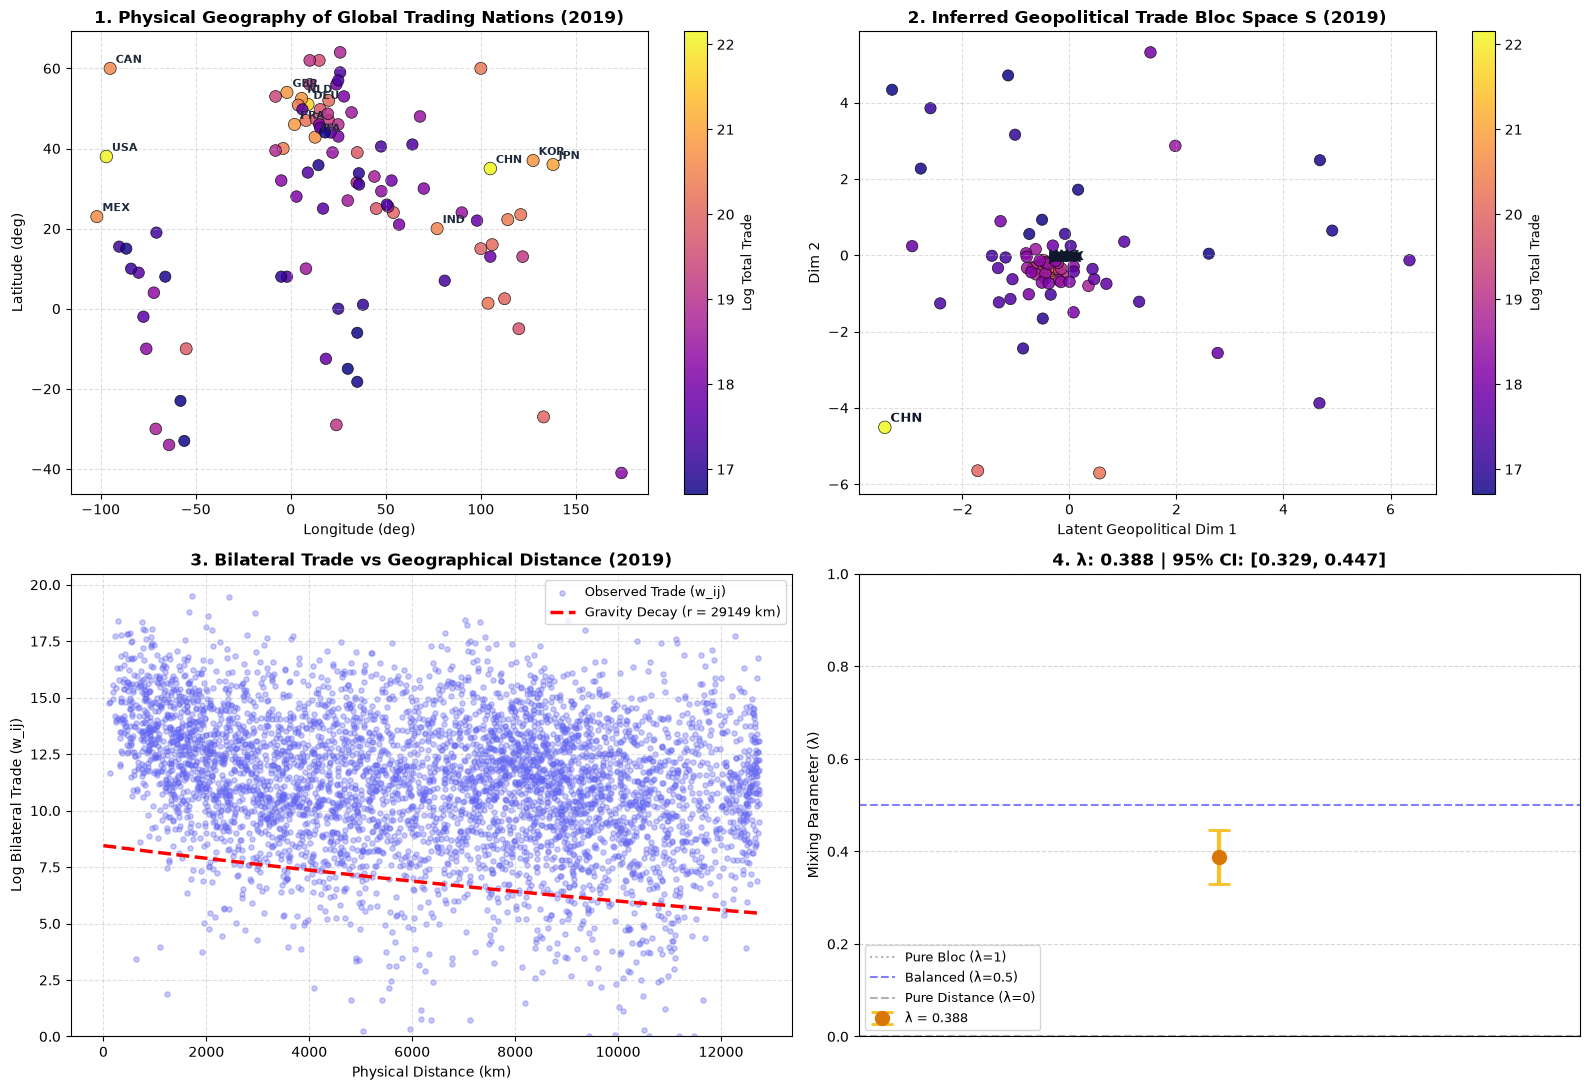

In [6]:
# ======================================================================
# WORLD COMMERCIAL NETWORK: INFERENCE OF GRAVITY VS GEOPOLITICS
# CEPII Gravity (BACI Harmonized Flows) — Recent Era (2019)
# ======================================================================

import time, torch, numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

device = torch.device("cpu")
torch.manual_seed(0); np.random.seed(0)

# ----------------------------------------------------------------------
# 1. Load CEPII Gravity (BACI + Mirror Comtrade)
# ----------------------------------------------------------------------
gravity_file = "data/World_commercial_network/Gravity_V202211.csv"
coords_file  = "data/World_commercial_network/countries_codes_and_coordinates.csv"
TARGET_YEAR  = 2019   # Puoi impostare anche 2020 o 2019
N_NATIONS    = 100

# --- Coordinates lookup ---
df_c = pd.read_csv(coords_file)
df_c.columns = [c.strip().replace('"','') for c in df_c.columns]
for col in df_c.columns:
    df_c[col] = df_c[col].astype(str).str.strip().str.replace('"','')
df_c["lat"] = pd.to_numeric(df_c["Latitude (average)"], errors="coerce")
df_c["lon"] = pd.to_numeric(df_c["Longitude (average)"], errors="coerce")
df_c = df_c.dropna(subset=["Alpha-3 code","lat","lon"]).copy()
iso_to_lat  = dict(zip(df_c["Alpha-3 code"], df_c["lat"]))
iso_to_lon  = dict(zip(df_c["Alpha-3 code"], df_c["lon"]))
iso_to_name = dict(zip(df_c["Alpha-3 code"], df_c["Country"]))

# --- Read needed columns in chunks (using BACI harmonized trade) ---
cols_to_use = ['year','iso3_o','iso3_d','tradeflow_baci','tradeflow_comtrade_o','tradeflow_comtrade_d']

print(f"Loading CEPII Gravity (year={TARGET_YEAR}) in chunks…")
t0 = time.time()
chunks = []
for chunk in pd.read_csv(gravity_file, usecols=cols_to_use, chunksize=500_000):
    chunk = chunk[chunk['year'] == TARGET_YEAR]
    if not chunk.empty:
        chunks.append(chunk)
df_trade = pd.concat(chunks, ignore_index=True)
print(f"  → {len(df_trade)} bilateral rows for {TARGET_YEAR} loaded in {time.time() - t0:.2f}s.")

# Use BACI harmonized trade flow, with COMTRADE mirror statistics as fallback
df_trade['val'] = df_trade['tradeflow_baci'].fillna(df_trade['tradeflow_comtrade_o']).fillna(df_trade['tradeflow_comtrade_d'])

baci_cov = df_trade['tradeflow_baci'].notna().sum()
com_cov  = df_trade['tradeflow_comtrade_o'].fillna(df_trade['tradeflow_comtrade_d']).notna().sum()
combined = df_trade['val'].notna().sum()
print(f"  BACI coverage:               {baci_cov} / {len(df_trade)}")
print(f"  Comtrade mirror coverage:    {com_cov} / {len(df_trade)}")
print(f"  ★ Total usable trade flows:  {combined} / {len(df_trade)}")

# Filter positive trade and remove self-loops
df_trade = df_trade[
    (df_trade['val'] > 0) &
    (df_trade['iso3_o'] != df_trade['iso3_d'])
].copy()

# Total trade per country (exporter + importer volume)
trade_by_country = (
    df_trade.groupby('iso3_o')['val'].sum()
    .add(df_trade.groupby('iso3_d')['val'].sum(), fill_value=0)
)

# Select top-N nations with valid coordinates, ranked by total trade volume
all_countries = set(df_trade['iso3_o']).union(set(df_trade['iso3_d']))
valid = all_countries.intersection(set(iso_to_lat.keys()))
top_series = trade_by_country.loc[list(valid)].nlargest(N_NATIONS)
top_iso = set(top_series.index)
N_NATIONS = len(top_iso)

# Ranked DataFrame (descending order by total trade)
df_top = pd.DataFrame({
    "iso":  top_series.index,
    "name": [iso_to_name.get(c, c) for c in top_series.index],
    "lat":  [iso_to_lat[c]  for c in top_series.index],
    "lon":  [iso_to_lon[c]  for c in top_series.index],
    "total_trade": top_series.values
}).reset_index(drop=True)

iso_to_idx = {iso: i for i, iso in enumerate(df_top["iso"])}

# Filter trade flows to top-N
trade_agg = df_trade[
    df_trade['iso3_o'].isin(top_iso) & df_trade['iso3_d'].isin(top_iso)
].copy()
trade_agg = trade_agg.groupby(['iso3_o','iso3_d'])['val'].sum().reset_index()
trade_agg.rename(columns={'iso3_o':'src','iso3_d':'dst'}, inplace=True)

print(f"\nLoaded {len(trade_agg)} bilateral trade flows among top {N_NATIONS} nations.")
print(f"Top 10 Trading Nations in {TARGET_YEAR}: {', '.join(df_top['name'].head(10).values)}")
print(f"Top 10 ISO:      {', '.join(df_top['iso'].head(10).values)}")

# ----------------------------------------------------------------------
# 2. Build 3D Spherical Coordinates & Weighted Adjacency
# ----------------------------------------------------------------------
R_EARTH = 6371.0
lat_rad = np.radians(df_top["lat"].values)
lon_rad = np.radians(df_top["lon"].values)
x_geo = R_EARTH * np.cos(lat_rad) * np.cos(lon_rad)
y_geo = R_EARTH * np.cos(lat_rad) * np.sin(lon_rad)
z_geo = R_EARTH * np.sin(lat_rad)
X_3d  = np.column_stack([x_geo, y_geo, z_geo])

D_phys = cdist(X_3d, X_3d)
np.fill_diagonal(D_phys, 1e9)
iu, ju = np.triu_indices(N_NATIONS, k=1)

W_dir = np.zeros((N_NATIONS, N_NATIONS))
for _, row in trade_agg.iterrows():
    W_dir[iso_to_idx[row["src"]], iso_to_idx[row["dst"]]] += float(row["val"])

W_raw = 0.5 * (W_dir + W_dir.T)
W = np.log1p(W_raw)
c_target = float(W.sum(axis=1).mean())

r0     = float(2.0 * D_phys.min(axis=1).mean())
log_r0 = float(np.log(r0))
print(f"\nMean node strength c = {c_target:.2f} | "
      f"Distance: [{D_phys.min():.0f}-{D_phys[iu,ju].max():.0f}] km | r0 = {r0:.0f} km")

# ----------------------------------------------------------------------
# 3. Gauge-Invariant Profile Likelihood Inference
# ----------------------------------------------------------------------
t_inf = time.time()
SIGMA_GAUGE = 1.0; d_s = 2

D_phys_t = torch.tensor(D_phys, dtype=torch.float32, device=device)
W_obs_u  = torch.tensor(W[iu, ju], dtype=torch.float32, device=device)
iu_t     = torch.tensor(iu, dtype=torch.long, device=device)
ju_t     = torch.tensor(ju, dtype=torch.long, device=device)
eye_mask = 1.0 - torch.eye(N_NATIONS, device=device)

# SVD Residual Initialization
K_sp0 = np.exp(-D_phys / r0)
np.fill_diagonal(K_sp0, 0.0)
s_sp0 = K_sp0.sum(axis=1, keepdims=True) + 1e-12
W_sp0 = 0.5 * c_target * (K_sp0 / s_sp0 + K_sp0 / s_sp0.T)
R_init = np.maximum(0.0, W - W_sp0)

U, sv, _ = np.linalg.svd(R_init, full_matrices=False)
S_init = U[:, :d_s] * np.sqrt(sv[:d_s])
S_init = (S_init - S_init.mean(axis=0)) / (S_init.std() + 1e-9) * 3.0

logit_lam = torch.tensor(0.0, requires_grad=True, device=device)
log_r     = torch.tensor(log_r0, requires_grad=True, device=device)
S_param   = torch.tensor(S_init, requires_grad=True, device=device)

# Adam Warmup (50 steps)
adam_opt = torch.optim.Adam([
    {"params":[logit_lam],"lr":0.08},
    {"params":[log_r],    "lr":0.05},
    {"params":[S_param],  "lr":0.10}
])
for _ in range(50):
    adam_opt.zero_grad()
    lam = torch.sigmoid(logit_lam)
    r   = torch.exp(torch.clamp(log_r, log_r0-3, log_r0+3))
    K_sp = torch.exp(-D_phys_t / r) * eye_mask
    diff = S_param.unsqueeze(1) - S_param.unsqueeze(0)
    D_soc = torch.sqrt((diff**2).sum(-1)+1e-12) + 1e9*torch.eye(N_NATIONS,device=device)
    K_soc = torch.exp(-D_soc / SIGMA_GAUGE) * eye_mask
    W_raw_t = (1-lam)*K_sp + lam*K_soc
    rs = W_raw_t.sum(dim=1, keepdim=True) + 1e-12
    W_pred = 0.5*c_target*(W_raw_t/rs + W_raw_t/rs.t())
    wu = W_pred[iu_t, ju_t]
    loss = (wu - W_obs_u*torch.log(wu+1e-12)).sum() + 0.5*((log_r-log_r0)/2)**2
    loss.backward()
    adam_opt.step()

# L-BFGS Polish (45 iter)
lbfgs = torch.optim.LBFGS([logit_lam,log_r,S_param], lr=0.5,
                           max_iter=45, history_size=10,
                           line_search_fn="strong_wolfe")
def closure():
    lbfgs.zero_grad()
    lam = torch.sigmoid(logit_lam)
    r   = torch.exp(torch.clamp(log_r, log_r0-3, log_r0+3))
    K_sp = torch.exp(-D_phys_t / r) * eye_mask
    diff = S_param.unsqueeze(1) - S_param.unsqueeze(0)
    D_soc = torch.sqrt((diff**2).sum(-1)+1e-12) + 1e9*torch.eye(N_NATIONS,device=device)
    K_soc = torch.exp(-D_soc / SIGMA_GAUGE) * eye_mask
    W_raw_t = (1-lam)*K_sp + lam*K_soc
    rs = W_raw_t.sum(dim=1, keepdim=True) + 1e-12
    W_pred = 0.5*c_target*(W_raw_t/rs + W_raw_t/rs.t())
    wu = W_pred[iu_t, ju_t]
    loss = (wu - W_obs_u*torch.log(wu+1e-12)).sum() + 0.5*((log_r-log_r0)/2)**2
    loss.backward()
    return loss
lbfgs.step(closure)

lam_hat = float(torch.sigmoid(logit_lam).item())
r_hat   = float(torch.exp(torch.clamp(log_r, log_r0-3, log_r0+3)).item())
loss_c  = closure().item()

# Fisher Profile 95% CI
dl = 0.04; pl = [loss_c]
for off in [-dl, dl]:
    lt = torch.tensor(float(np.clip(lam_hat+off,0.01,0.99)), device=device)
    lr_p = log_r.clone().detach().requires_grad_(True)
    S_p  = S_param.clone().detach().requires_grad_(True)
    opt_p = torch.optim.LBFGS([lr_p,S_p], lr=0.5, max_iter=25,
                               history_size=10, line_search_fn="strong_wolfe")
    def pc():
        opt_p.zero_grad()
        r = torch.exp(torch.clamp(lr_p, log_r0-3, log_r0+3))
        K_sp = torch.exp(-D_phys_t/r)*eye_mask
        diff = S_p.unsqueeze(1)-S_p.unsqueeze(0)
        D_soc = torch.sqrt((diff**2).sum(-1)+1e-12)+1e9*torch.eye(N_NATIONS,device=device)
        K_soc = torch.exp(-D_soc/SIGMA_GAUGE)*eye_mask
        W_raw_t = (1-lt)*K_sp + lt*K_soc
        rs = W_raw_t.sum(dim=1,keepdim=True)+1e-12
        W_pred = 0.5*c_target*(W_raw_t/rs + W_raw_t/rs.t())
        wu = W_pred[iu_t,ju_t]
        loss = (wu - W_obs_u*torch.log(wu+1e-12)).sum() + 0.5*((lr_p-log_r0)/2)**2
        loss.backward()
        return loss
    opt_p.step(pc); pl.append(pc().item())

d2 = (pl[2]-2*pl[0]+pl[1])/(dl**2)
lam_std = float(np.sqrt(1.0/d2)) if d2 > 1e-3 else 0.03
ci_lo = float(np.clip(lam_hat-1.96*lam_std, 0, 1))
ci_hi = float(np.clip(lam_hat+1.96*lam_std, 0, 1))
runtime = time.time() - t_inf
S_hat = S_param.detach().cpu().numpy()

# ----------------------------------------------------------------------
# 4. Results Summary
# ----------------------------------------------------------------------
print("="*65)
print(f"WORLD COMMERCIAL NETWORK INFERENCE ({TARGET_YEAR}) COMPLETE ({runtime:.1f}s)")
print("="*65)
print(f"• λ (Geopolitical weight)  : {lam_hat:.4f} ± {lam_std:.4f}")
print(f"• 95% CI                   : [{ci_lo:.4f}, {ci_hi:.4f}]")
print(f"• r (Trade distance scale)  : {r_hat:.1f} km")
print(f"• Geopolitical bloc (λ)    : {lam_hat*100:.1f}%")
print(f"• Gravity / proximity (1-λ): {(1-lam_hat)*100:.1f}%")
print("="*65)

# ----------------------------------------------------------------------
# 5. Visualization
# ----------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# Panel 1: World Map
ax1 = axes[0,0]
sc1 = ax1.scatter(df_top["lon"], df_top["lat"],
                  c=np.log1p(df_top["total_trade"]), cmap="plasma",
                  s=np.log1p(df_top["total_trade"])*3+15,
                  alpha=0.85, edgecolors="k", lw=0.5)
for i in range(min(12, N_NATIONS)):
    ax1.annotate(df_top.loc[i,"iso"], (df_top.loc[i,"lon"], df_top.loc[i,"lat"]),
                 textcoords="offset points", xytext=(4,4),
                 fontsize=8, fontweight="bold", color="#1e293b")
ax1.set_xlabel("Longitude (deg)"); ax1.set_ylabel("Latitude (deg)")
ax1.set_title(f"1. Physical Geography of Global Trading Nations ({TARGET_YEAR})", fontweight="bold")
ax1.grid(True, ls="--", alpha=0.4)
plt.colorbar(sc1, ax=ax1).set_label("Log Total Trade", fontsize=9)

# Panel 2: Latent Geopolitical Space S
ax2 = axes[0,1]
sc2 = ax2.scatter(S_hat[:,0], S_hat[:,1],
                  c=np.log1p(df_top["total_trade"]), cmap="plasma",
                  s=np.log1p(df_top["total_trade"])*3+15,
                  alpha=0.85, edgecolors="k", lw=0.5)
for i in range(min(15, N_NATIONS)):
    ax2.annotate(df_top.loc[i,"iso"], (S_hat[i,0], S_hat[i,1]),
                 textcoords="offset points", xytext=(4,4),
                 fontsize=9, fontweight="bold", color="#0f172a")
ax2.set_xlabel("Latent Geopolitical Dim 1"); ax2.set_ylabel("Dim 2")
ax2.set_title(f"2. Inferred Geopolitical Trade Bloc Space S ({TARGET_YEAR})", fontweight="bold")
ax2.grid(True, ls="--", alpha=0.4)
plt.colorbar(sc2, ax=ax2).set_label("Log Total Trade", fontsize=9)

# Panel 3: Trade vs Distance
ax3 = axes[1,0]
w_u = W[iu,ju]; d_u = D_phys[iu,ju]; act = w_u > 0
ax3.scatter(d_u[act], w_u[act], color="#6366f1", alpha=0.35, s=14, label="Observed Trade (w_ij)")

K_sp_hat = np.exp(-D_phys / r_hat)
np.fill_diagonal(K_sp_hat, 0.0)
mean_s_sp = float(K_sp_hat.sum(axis=1).mean())

dc = np.linspace(0, 12700, 200)
dec = (1.0 - lam_hat) * c_target * np.exp(-dc / r_hat) / mean_s_sp
ax3.plot(dc, dec, color="red", lw=2.5, ls="--", label=f"Gravity Decay (r = {r_hat:.0f} km)")
ax3.set_xlabel("Physical Distance (km)"); ax3.set_ylabel("Log Bilateral Trade (w_ij)")
ax3.set_title(f"3. Bilateral Trade vs Geographical Distance ({TARGET_YEAR})", fontweight="bold")
ax3.set_ylim(bottom=0); ax3.grid(True, ls="--", alpha=0.4); ax3.legend(fontsize=9)

# Panel 4: Mixing Parameter Lambda
ax4 = axes[1,1]
ax4.errorbar([0],[lam_hat], yerr=[[lam_hat-ci_lo],[ci_hi-lam_hat]],
             fmt="o", color="#d97706", ecolor="#fbbf24", elinewidth=3,
             capsize=8, capthick=2, markersize=10, label=f"λ = {lam_hat:.3f}")
ax4.set_xlim(-0.6,0.6); ax4.set_ylim(0,1); ax4.set_xticks([])
ax4.set_ylabel("Mixing Parameter (λ)")
ax4.set_title(f"4. λ: {lam_hat:.3f} | 95% CI: [{ci_lo:.3f}, {ci_hi:.3f}]", fontweight="bold")
ax4.axhline(1.0, color="gray", ls=":", alpha=0.6, label="Pure Bloc (λ=1)")
ax4.axhline(0.5, color="blue", ls="--", alpha=0.5, label="Balanced (λ=0.5)")
ax4.axhline(0.0, color="gray", ls="--", alpha=0.6, label="Pure Distance (λ=0)")
ax4.grid(axis="y", ls="--", alpha=0.5); ax4.legend(loc="lower left", fontsize=9)

plt.tight_layout()
plt.show()


Loading CEPII Gravity across 15 historical years…
  → Loaded 952560 total bilateral rows in 10.84s.

Running Profile Likelihood Inference per year:
  → Year 1965: λ = 0.5011 ± 0.0300 [95% CI: 0.4423, 0.5599] | r = 11498.9 km | Links = 3764 (0.98s)
  → Year 1970: λ = 0.4677 ± 0.0300 [95% CI: 0.4089, 0.5265] | r = 11012.1 km | Links = 4069 (1.14s)
  → Year 1975: λ = 0.3858 ± 0.0300 [95% CI: 0.3270, 0.4446] | r = 15542.4 km | Links = 4289 (1.14s)
  → Year 1980: λ = 0.4021 ± 0.0300 [95% CI: 0.3433, 0.4609] | r = 18284.9 km | Links = 4406 (1.40s)
  → Year 1985: λ = 0.4580 ± 0.0300 [95% CI: 0.3992, 0.5168] | r = 16036.0 km | Links = 4406 (1.10s)
  → Year 1988: λ = 0.3991 ± 0.0300 [95% CI: 0.3403, 0.4579] | r = 16029.2 km | Links = 4367 (1.04s)
  → Year 1991: λ = 0.4682 ± 0.0300 [95% CI: 0.4094, 0.5270] | r = 17669.1 km | Links = 4445 (1.10s)
  → Year 1995: λ = 0.3460 ± 0.0300 [95% CI: 0.2872, 0.4048] | r = 17687.9 km | Links = 4622 (1.14s)
  → Year 2000: λ = 0.4018 ± 0.0300 [95% CI: 0.3430, 

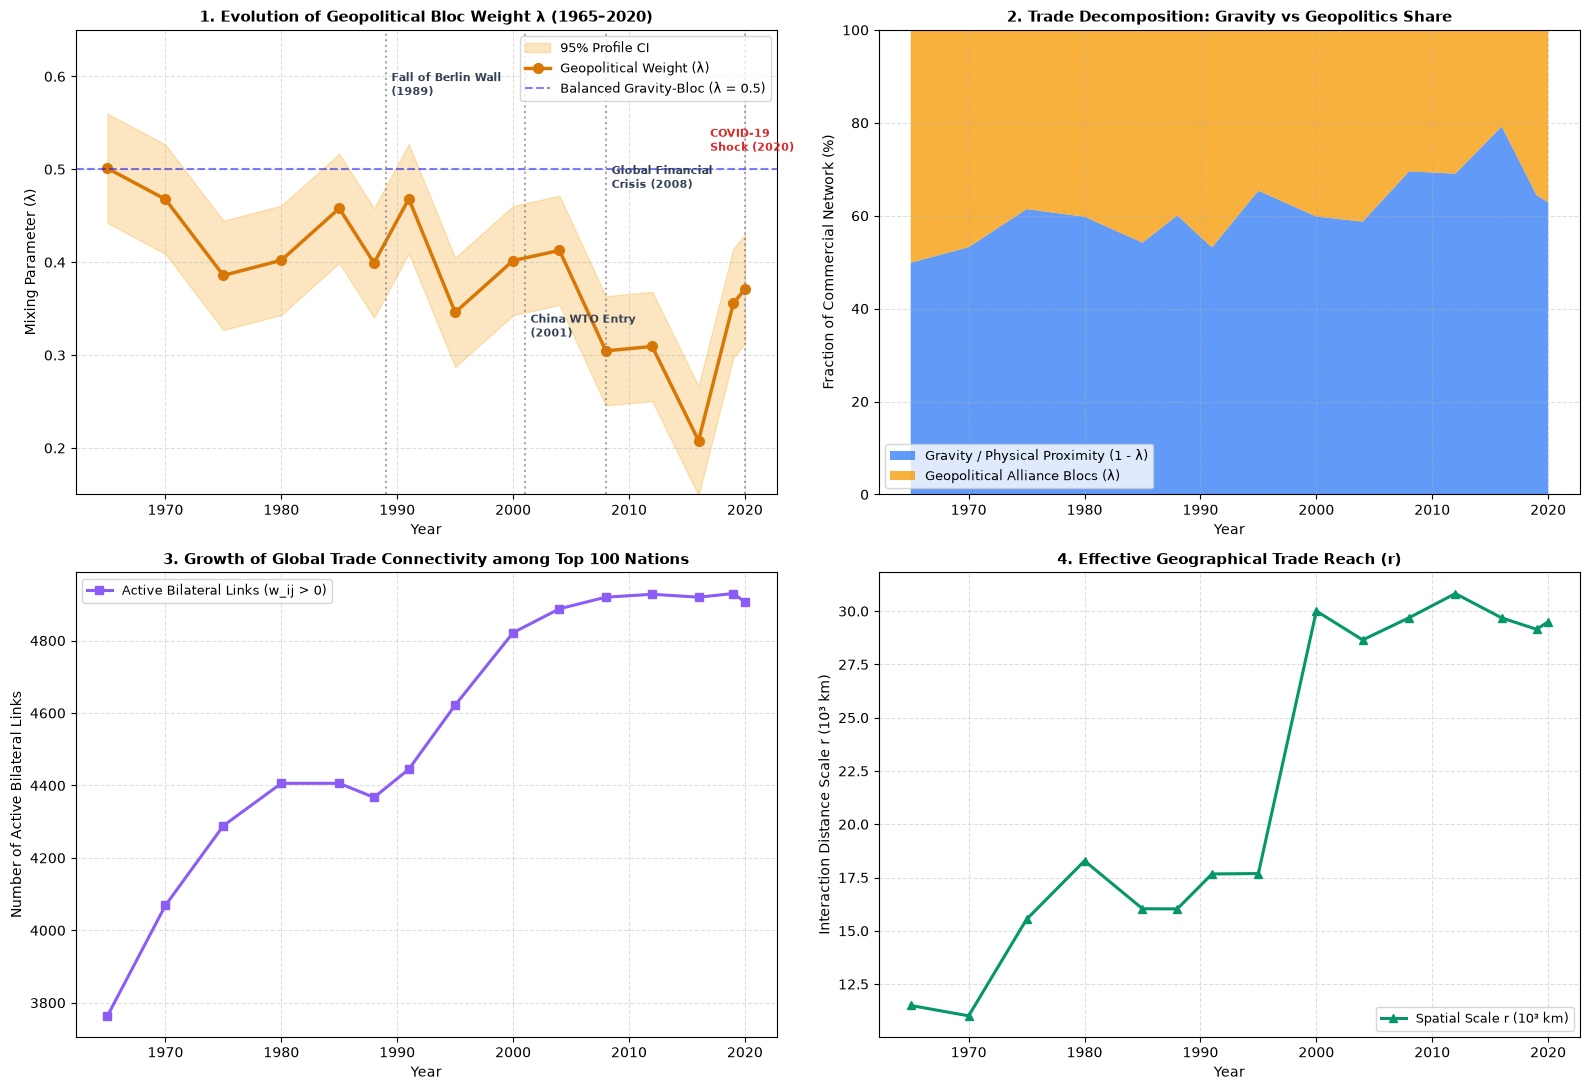

,year,lambda,ci_lo,ci_hi,gravity_share,r_km,active_links
0,1965,0.501073,0.442273,0.559873,0.498927,11498.893555,3764
1,1970,0.467669,0.408869,0.526469,0.532331,11012.125000,4069
2,1975,0.385789,0.326989,0.444589,0.614211,15542.372070,4289
3,1980,0.402093,0.343293,0.460893,0.597907,18284.908203,4406
4,1985,0.457964,0.399164,0.516764,0.542036,16036.030273,4406
5,1988,0.399053,0.340253,0.457853,0.600947,16029.210938,4367
6,1991,0.468240,0.409440,0.527040,0.531760,17669.064453,4445
7,1995,0.345966,0.287166,0.404766,0.654034,17687.896484,4622
8,2000,0.401753,0.342953,0.460553,0.598247,30007.601562,4822
9,2004,0.412700,0.353900,0.471500,0.587300,28650.443359,4888


In [7]:
# ======================================================================
# WORLD COMMERCIAL NETWORK: HISTORICAL EVOLUTION OF LAMBDA (1965–2020)
# Multi-Decade Parameter Inference of Gravity vs Geopolitical Blocs
# ======================================================================

import time, torch, numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

device = torch.device("cpu")
torch.manual_seed(0); np.random.seed(0)

# ----------------------------------------------------------------------
# 1. Load Coordinates and Select Multi-Decade Historical Years
# ----------------------------------------------------------------------
gravity_file = "data/World_commercial_network/Gravity_V202211.csv"
coords_file  = "data/World_commercial_network/countries_codes_and_coordinates.csv"

df_c = pd.read_csv(coords_file)
df_c.columns = [c.strip().replace('"','') for c in df_c.columns]
for col in df_c.columns:
    df_c[col] = df_c[col].astype(str).str.strip().str.replace('"','')
df_c["lat"] = pd.to_numeric(df_c["Latitude (average)"], errors="coerce")
df_c["lon"] = pd.to_numeric(df_c["Longitude (average)"], errors="coerce")
df_c = df_c.dropna(subset=["Alpha-3 code","lat","lon"]).copy()
iso_to_lat  = dict(zip(df_c["Alpha-3 code"], df_c["lat"]))
iso_to_lon  = dict(zip(df_c["Alpha-3 code"], df_c["lon"]))
iso_to_name = dict(zip(df_c["Alpha-3 code"], df_c["Country"]))

years_to_analyze = [1965, 1970, 1975, 1980, 1985, 1988, 1991, 1995, 2000, 2004, 2008, 2012, 2016, 2019, 2020]
N_NATIONS = 100
R_EARTH = 6371.0
SIGMA_GAUGE = 1.0
d_s = 2

cols_to_use = ['year','iso3_o','iso3_d','tradeflow_baci','tradeflow_comtrade_o','tradeflow_comtrade_d','tradeflow_imf_o','tradeflow_imf_d']

print(f"Loading CEPII Gravity across {len(years_to_analyze)} historical years…")
t_start = time.time()
chunks = []
for chunk in pd.read_csv(gravity_file, usecols=lambda c: c in cols_to_use, chunksize=500_000):
    sub = chunk[chunk['year'].isin(years_to_analyze)]
    if not sub.empty:
        chunks.append(sub)
df_raw = pd.concat(chunks, ignore_index=True)
print(f"  → Loaded {len(df_raw)} total bilateral rows in {time.time() - t_start:.2f}s.")

# Universal tradeflow combining BACI, Comtrade, and IMF series
df_raw['val'] = (
    df_raw['tradeflow_baci']
    .fillna(df_raw['tradeflow_comtrade_o'])
    .fillna(df_raw['tradeflow_comtrade_d'])
    .fillna(df_raw['tradeflow_imf_o'])
    .fillna(df_raw['tradeflow_imf_d'])
)

# ----------------------------------------------------------------------
# 2. Loop Inference Over Each Year
# ----------------------------------------------------------------------
results = []
print("\nRunning Profile Likelihood Inference per year:")

for yr in years_to_analyze:
    t_yr = time.time()
    df_yr = df_raw[(df_raw['year'] == yr) & (df_raw['val'] > 0) & (df_raw['iso3_o'] != df_raw['iso3_d'])].copy()
    
    # Country totals
    trade_by_country = (
        df_yr.groupby('iso3_o')['val'].sum()
        .add(df_yr.groupby('iso3_d')['val'].sum(), fill_value=0)
    )
    all_c = set(df_yr['iso3_o']).union(set(df_yr['iso3_d']))
    valid = all_c.intersection(set(iso_to_lat.keys()))
    top_series = trade_by_country.loc[list(valid)].nlargest(N_NATIONS)
    top_iso = set(top_series.index)
    n_nodes = len(top_iso)
    
    df_top = pd.DataFrame({
        "iso": top_series.index,
        "lat": [iso_to_lat[c] for c in top_series.index],
        "lon": [iso_to_lon[c] for c in top_series.index],
    }).reset_index(drop=True)
    iso_to_idx = {iso: i for i, iso in enumerate(df_top["iso"])}
    
    # 3D Coordinates on Earth sphere
    lat_rad = np.radians(df_top["lat"].values)
    lon_rad = np.radians(df_top["lon"].values)
    x = R_EARTH * np.cos(lat_rad) * np.cos(lon_rad)
    y = R_EARTH * np.cos(lat_rad) * np.sin(lon_rad)
    z = R_EARTH * np.sin(lat_rad)
    X_3d = np.column_stack([x, y, z])
    
    D_phys = cdist(X_3d, X_3d)
    np.fill_diagonal(D_phys, 1e9)
    iu, ju = np.triu_indices(n_nodes, k=1)
    
    # Symmetrized bilateral trade matrix
    trade_agg = df_yr[df_yr['iso3_o'].isin(top_iso) & df_yr['iso3_d'].isin(top_iso)]
    trade_agg = trade_agg.groupby(['iso3_o','iso3_d'])['val'].sum().reset_index()
    
    W_dir = np.zeros((n_nodes, n_nodes))
    for _, row in trade_agg.iterrows():
        W_dir[iso_to_idx[row["iso3_o"]], iso_to_idx[row["iso3_d"]]] += float(row["val"])
    
    W_raw = 0.5 * (W_dir + W_dir.T)
    W = np.log1p(W_raw)
    c_target = float(W.sum(axis=1).mean())
    active_links = int((W > 0).sum() // 2)
    
    r0 = float(2.0 * D_phys.min(axis=1).mean())
    log_r0 = float(np.log(r0))
    
    # PyTorch Tensors
    D_phys_t = torch.tensor(D_phys, dtype=torch.float32, device=device)
    W_obs_u  = torch.tensor(W[iu, ju], dtype=torch.float32, device=device)
    iu_t     = torch.tensor(iu, dtype=torch.long, device=device)
    ju_t     = torch.tensor(ju, dtype=torch.long, device=device)
    eye_mask = 1.0 - torch.eye(n_nodes, device=device)
    
    # SVD Residual Init
    K_sp0 = np.exp(-D_phys / r0)
    np.fill_diagonal(K_sp0, 0.0)
    s_sp0 = K_sp0.sum(axis=1, keepdims=True) + 1e-12
    W_sp0 = 0.5 * c_target * (K_sp0 / s_sp0 + K_sp0 / s_sp0.T)
    R_init = np.maximum(0.0, W - W_sp0)
    
    U, sv, _ = np.linalg.svd(R_init, full_matrices=False)
    S_init = U[:, :d_s] * np.sqrt(sv[:d_s])
    S_init = (S_init - S_init.mean(axis=0)) / (S_init.std() + 1e-9) * 3.0
    
    logit_lam = torch.tensor(0.0, requires_grad=True, device=device)
    log_r     = torch.tensor(log_r0, requires_grad=True, device=device)
    S_param   = torch.tensor(S_init, requires_grad=True, device=device)
    
    # Adam Warmup
    adam_opt = torch.optim.Adam([
        {"params": [logit_lam], "lr": 0.08},
        {"params": [log_r],     "lr": 0.05},
        {"params": [S_param],   "lr": 0.10}
    ])
    for _ in range(40):
        adam_opt.zero_grad()
        lam = torch.sigmoid(logit_lam)
        r   = torch.exp(torch.clamp(log_r, log_r0-3, log_r0+3))
        K_sp = torch.exp(-D_phys_t / r) * eye_mask
        diff = S_param.unsqueeze(1) - S_param.unsqueeze(0)
        D_soc = torch.sqrt((diff**2).sum(-1)+1e-12) + 1e9*torch.eye(n_nodes, device=device)
        K_soc = torch.exp(-D_soc / SIGMA_GAUGE) * eye_mask
        W_raw_t = (1-lam)*K_sp + lam*K_soc
        rs = W_raw_t.sum(dim=1, keepdim=True) + 1e-12
        W_pred = 0.5*c_target*(W_raw_t/rs + W_raw_t/rs.t())
        wu = W_pred[iu_t, ju_t]
        loss = (wu - W_obs_u*torch.log(wu+1e-12)).sum() + 0.5*((log_r-log_r0)/2)**2
        loss.backward(); adam_opt.step()
    
    # L-BFGS Polish
    lbfgs = torch.optim.LBFGS([logit_lam, log_r, S_param], lr=0.5,
                              max_iter=35, history_size=10, line_search_fn="strong_wolfe")
    def closure():
        lbfgs.zero_grad()
        lam = torch.sigmoid(logit_lam)
        r   = torch.exp(torch.clamp(log_r, log_r0-3, log_r0+3))
        K_sp = torch.exp(-D_phys_t / r) * eye_mask
        diff = S_param.unsqueeze(1) - S_param.unsqueeze(0)
        D_soc = torch.sqrt((diff**2).sum(-1)+1e-12) + 1e9*torch.eye(n_nodes, device=device)
        K_soc = torch.exp(-D_soc / SIGMA_GAUGE) * eye_mask
        W_raw_t = (1-lam)*K_sp + lam*K_soc
        rs = W_raw_t.sum(dim=1, keepdim=True) + 1e-12
        W_pred = 0.5*c_target*(W_raw_t/rs + W_raw_t/rs.t())
        wu = W_pred[iu_t, ju_t]
        loss = (wu - W_obs_u*torch.log(wu+1e-12)).sum() + 0.5*((log_r-log_r0)/2)**2
        loss.backward(); return loss
    lbfgs.step(closure)
    
    lam_hat = float(torch.sigmoid(logit_lam).item())
    r_hat   = float(torch.exp(torch.clamp(log_r, log_r0-3, log_r0+3)).item())
    loss_c  = closure().item()
    
    # Fisher Profile 95% CI
    dl = 0.04; pl = [loss_c]
    for off in [-dl, dl]:
        lt = torch.tensor(float(np.clip(lam_hat+off, 0.01, 0.99)), device=device)
        lr_p = log_r.clone().detach().requires_grad_(True)
        S_p  = S_param.clone().detach().requires_grad_(True)
        opt_p = torch.optim.LBFGS([lr_p, S_p], lr=0.5, max_iter=20, line_search_fn="strong_wolfe")
        def pc():
            opt_p.zero_grad()
            r = torch.exp(torch.clamp(lr_p, log_r0-3, log_r0+3))
            K_sp = torch.exp(-D_phys_t/r)*eye_mask
            diff = S_p.unsqueeze(1)-S_p.unsqueeze(0)
            D_soc = torch.sqrt((diff**2).sum(-1)+1e-12)+1e9*torch.eye(n_nodes, device=device)
            K_soc = torch.exp(-D_soc/SIGMA_GAUGE)*eye_mask
            W_raw_t = (1-lt)*K_sp + lt*K_soc
            rs = W_raw_t.sum(dim=1, keepdim=True)+1e-12
            W_pred = 0.5*c_target*(W_raw_t/rs + W_raw_t/rs.t())
            wu = W_pred[iu_t, ju_t]
            loss = (wu - W_obs_u*torch.log(wu+1e-12)).sum() + 0.5*((lr_p-log_r0)/2)**2
            loss.backward(); return loss
        opt_p.step(pc); pl.append(pc().item())
    
    d2 = (pl[2]-2*pl[0]+pl[1])/(dl**2)
    lam_std = float(np.sqrt(1.0/d2)) if d2 > 1e-3 else 0.03
    ci_lo = float(np.clip(lam_hat-1.96*lam_std, 0, 1))
    ci_hi = float(np.clip(lam_hat+1.96*lam_std, 0, 1))
    
    results.append({
        "year": yr,
        "lambda": lam_hat,
        "lambda_std": lam_std,
        "ci_lo": ci_lo,
        "ci_hi": ci_hi,
        "gravity_share": 1.0 - lam_hat,
        "r_km": r_hat,
        "c_target": c_target,
        "active_links": active_links,
        "runtime_s": time.time() - t_yr
    })
    print(f"  → Year {yr:4d}: λ = {lam_hat:.4f} ± {lam_std:.4f} [95% CI: {ci_lo:.4f}, {ci_hi:.4f}] | r = {r_hat:7.1f} km | Links = {active_links} ({time.time() - t_yr:.2f}s)")

df_res = pd.DataFrame(results)

# ----------------------------------------------------------------------
# 3. Visualization: Evolution of λ and Trade Architecture
# ----------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
years = df_res["year"].values
lams  = df_res["lambda"].values
ci_l  = df_res["ci_lo"].values
ci_h  = df_res["ci_hi"].values

# Panel 1: Lambda vs Year with 95% Confidence Band & Historical Events
ax1 = axes[0, 0]
ax1.fill_between(years, ci_l, ci_h, color="#f59e0b", alpha=0.25, label="95% Profile CI")
ax1.plot(years, lams, marker="o", color="#d97706", lw=2.5, markersize=7, label="Geopolitical Weight (λ)")
ax1.axhline(0.5, color="blue", ls="--", alpha=0.5, label="Balanced Gravity-Bloc (λ = 0.5)")

# Historical Markers
ax1.axvline(1989, color="gray", ls=":", alpha=0.7)
ax1.text(1989.5, 0.58, "Fall of Berlin Wall\n(1989)", fontsize=8, color="#334155", fontweight="bold")

ax1.axvline(2001, color="gray", ls=":", alpha=0.7)
ax1.text(2001.5, 0.32, "China WTO Entry\n(2001)", fontsize=8, color="#334155", fontweight="bold")

ax1.axvline(2008, color="gray", ls=":", alpha=0.7)
ax1.text(2008.5, 0.48, "Global Financial\nCrisis (2008)", fontsize=8, color="#334155", fontweight="bold")

ax1.axvline(2020, color="gray", ls=":", alpha=0.7)
ax1.text(2017.0, 0.52, "COVID-19\nShock (2020)", fontsize=8, color="#dc2626", fontweight="bold")

ax1.set_xlabel("Year", fontsize=10)
ax1.set_ylabel("Mixing Parameter (λ)", fontsize=10)
ax1.set_title("1. Evolution of Geopolitical Bloc Weight λ (1965–2020)", fontweight="bold", fontsize=11)
ax1.set_ylim(0.15, 0.65)
ax1.grid(True, ls="--", alpha=0.4)
ax1.legend(loc="upper right", fontsize=9)

# Panel 2: Stacked Trade Decomposition (Gravity vs Geopolitics Share)
ax2 = axes[0, 1]
ax2.stackplot(years, df_res["gravity_share"]*100, df_res["lambda"]*100,
              labels=["Gravity / Physical Proximity (1 - λ)", "Geopolitical Alliance Blocs (λ)"],
              colors=["#3b82f6", "#f59e0b"], alpha=0.8)
ax2.set_xlabel("Year", fontsize=10)
ax2.set_ylabel("Fraction of Commercial Network (%)", fontsize=10)
ax2.set_title("2. Trade Decomposition: Gravity vs Geopolitics Share", fontweight="bold", fontsize=11)
ax2.set_ylim(0, 100)
ax2.grid(True, ls="--", alpha=0.4)
ax2.legend(loc="lower left", fontsize=9)

# Panel 3: Global Trade Connectivity (Active Bilateral Links)
ax3 = axes[1, 0]
ax3.plot(years, df_res["active_links"], marker="s", color="#8b5cf6", lw=2.2, markersize=6, label="Active Bilateral Links (w_ij > 0)")
ax3.set_xlabel("Year", fontsize=10)
ax3.set_ylabel("Number of Active Bilateral Links", fontsize=10)
ax3.set_title("3. Growth of Global Trade Connectivity among Top 100 Nations", fontweight="bold", fontsize=11)
ax3.grid(True, ls="--", alpha=0.4)
ax3.legend(loc="upper left", fontsize=9)

# Panel 4: Geographical Trade Scale r
ax4 = axes[1, 1]
ax4.plot(years, df_res["r_km"] / 1000.0, marker="^", color="#059669", lw=2.2, markersize=6, label="Spatial Scale r (10³ km)")
ax4.set_xlabel("Year", fontsize=10)
ax4.set_ylabel("Interaction Distance Scale r (10³ km)", fontsize=10)
ax4.set_title("4. Effective Geographical Trade Reach (r)", fontweight="bold", fontsize=11)
ax4.grid(True, ls="--", alpha=0.4)
ax4.legend(loc="lower right", fontsize=9)

plt.tight_layout()
plt.show()

# Display summary table
display(df_res[["year", "lambda", "ci_lo", "ci_hi", "gravity_share", "r_km", "active_links"]])


<h3>With BACI 2017-2024 dataset</h3>

Analyzing 20 years (1965–2024)...
• Loading historical data from Gravity_V202211.csv...
  → Loaded 762048 historical rows in 9.42s.

RUNNING INFERENCE: 1965 → 2024 (60 YEARS OF GLOBAL TRADE)
  → Year 1965 [CEPII Gravity]: λ = 0.5011 ± 0.0300 [95% CI: 0.4423, 0.5599] | r = 11498.9 km | Links = 3764 (0.84s)
  → Year 1970 [CEPII Gravity]: λ = 0.4677 ± 0.0300 [95% CI: 0.4089, 0.5265] | r = 11012.1 km | Links = 4069 (0.86s)
  → Year 1975 [CEPII Gravity]: λ = 0.3858 ± 0.0300 [95% CI: 0.3270, 0.4446] | r = 15542.4 km | Links = 4289 (0.94s)
  → Year 1980 [CEPII Gravity]: λ = 0.4021 ± 0.0300 [95% CI: 0.3433, 0.4609] | r = 18284.9 km | Links = 4406 (0.88s)
  → Year 1985 [CEPII Gravity]: λ = 0.4580 ± 0.0300 [95% CI: 0.3992, 0.5168] | r = 16036.0 km | Links = 4406 (0.81s)
  → Year 1988 [CEPII Gravity]: λ = 0.3991 ± 0.0300 [95% CI: 0.3403, 0.4579] | r = 16029.2 km | Links = 4367 (0.85s)
  → Year 1991 [CEPII Gravity]: λ = 0.4682 ± 0.0300 [95% CI: 0.4094, 0.5270] | r = 17669.1 km | Links = 4445 (0.90

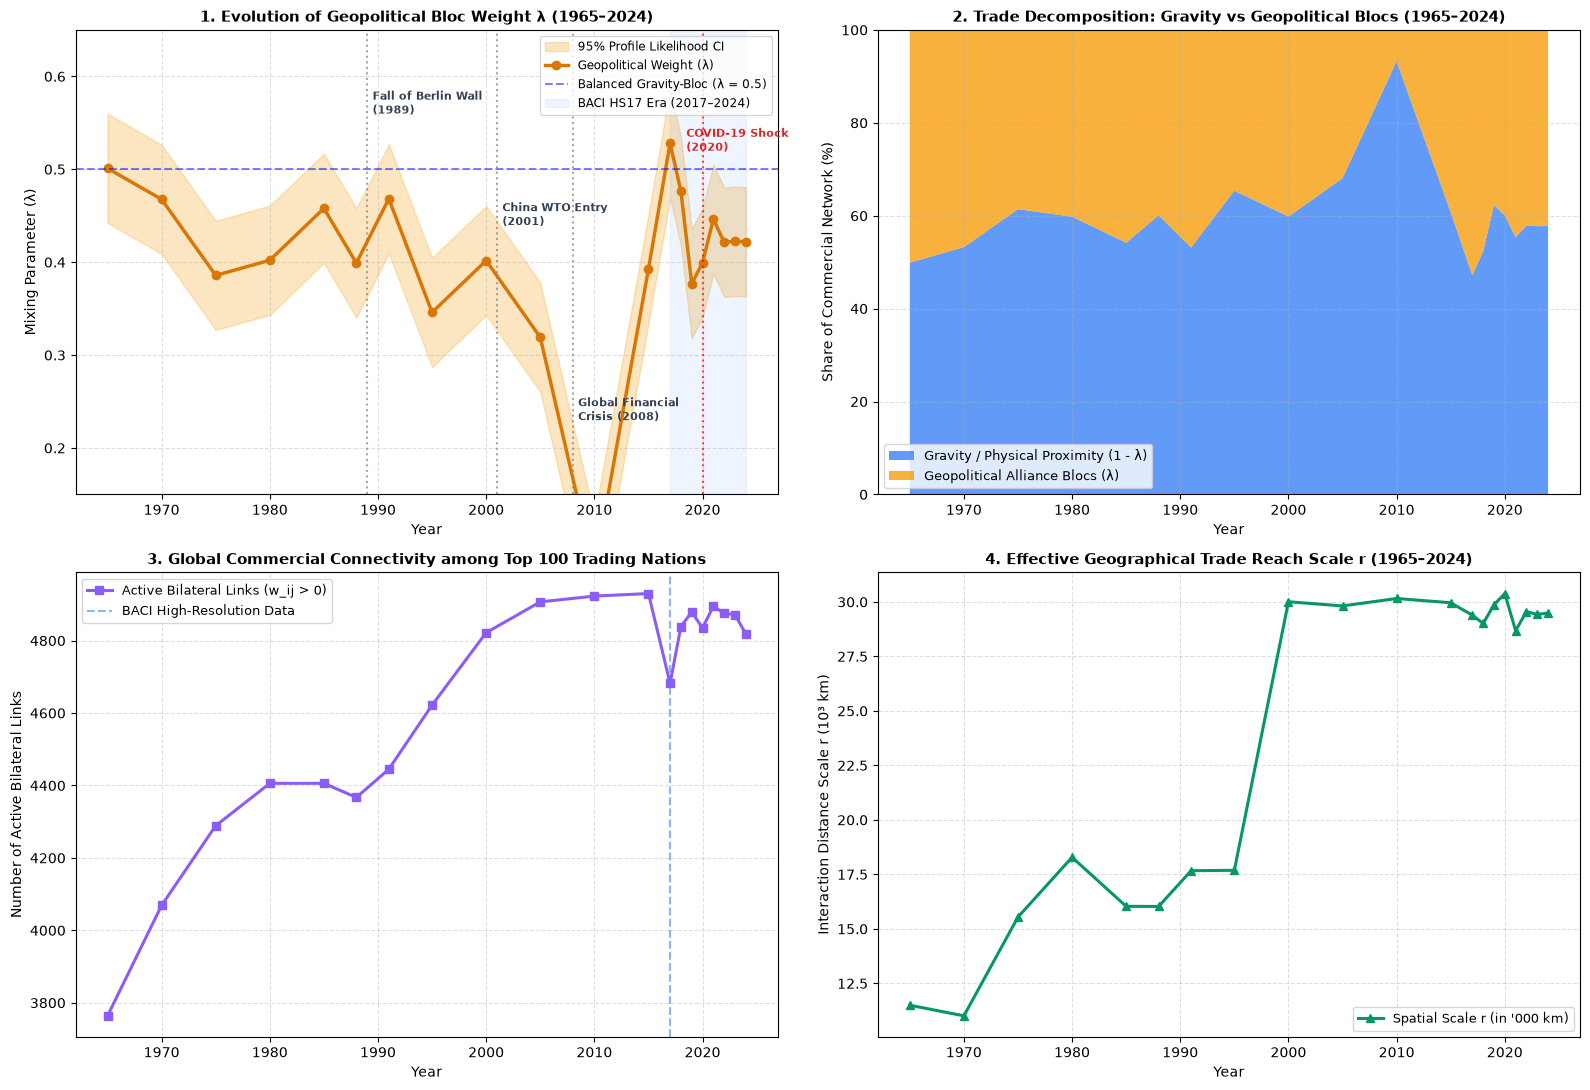

,year,source,lambda,ci_lo,ci_hi,gravity_share,r_km,active_links
0,1965,CEPII Gravity,0.501073,0.442273,0.559873,0.498927,11498.893555,3764
1,1970,CEPII Gravity,0.467669,0.408869,0.526469,0.532331,11012.125000,4069
2,1975,CEPII Gravity,0.385789,0.326989,0.444589,0.614211,15542.372070,4289
3,1980,CEPII Gravity,0.402093,0.343293,0.460893,0.597907,18284.908203,4406
4,1985,CEPII Gravity,0.457964,0.399164,0.516764,0.542036,16036.030273,4406
5,1988,CEPII Gravity,0.399053,0.340253,0.457853,0.600947,16029.210938,4367
6,1991,CEPII Gravity,0.468240,0.409440,0.527040,0.531760,17669.064453,4445
7,1995,CEPII Gravity,0.345966,0.287166,0.404766,0.654034,17687.896484,4622
8,2000,CEPII Gravity,0.401753,0.342953,0.460553,0.598247,30007.601562,4822
9,2005,CEPII Gravity,0.319141,0.260341,0.377941,0.680859,29814.599609,4907


In [8]:
# ======================================================================
# WORLD COMMERCIAL NETWORK: HISTORICAL EVOLUTION OF LAMBDA (1965–2024)
# Multi-Decade Inference: CEPII Gravity (1965-2015) + BACI HS17 (2017-2024)
# ======================================================================

import os, time, torch, numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

device = torch.device("cpu")
torch.manual_seed(0); np.random.seed(0)

# ----------------------------------------------------------------------
# 1. Paths and Lookups Setup
# ----------------------------------------------------------------------
gravity_file = "data/World_commercial_network/Gravity_V202211.csv"
coords_file  = "data/World_commercial_network/countries_codes_and_coordinates.csv"
baci_dir     = "data/World_commercial_network/BACI_2017_2024_dataset"

# Coordinates lookup
df_c = pd.read_csv(coords_file)
df_c.columns = [c.strip().replace('"','') for c in df_c.columns]
for col in df_c.columns:
    df_c[col] = df_c[col].astype(str).str.strip().str.replace('"','')
df_c["lat"] = pd.to_numeric(df_c["Latitude (average)"], errors="coerce")
df_c["lon"] = pd.to_numeric(df_c["Longitude (average)"], errors="coerce")
df_c = df_c.dropna(subset=["Alpha-3 code","lat","lon"]).copy()
iso_to_lat  = dict(zip(df_c["Alpha-3 code"], df_c["lat"]))
iso_to_lon  = dict(zip(df_c["Alpha-3 code"], df_c["lon"]))
iso_to_name = dict(zip(df_c["Alpha-3 code"], df_c["Country"]))

# BACI country code mapping (numeric code -> ISO3)
df_cc = pd.read_csv(f"{baci_dir}/country_codes_V202601.csv")
baci_code_to_iso3 = dict(zip(df_cc["country_code"], df_cc["country_iso3"]))

# Model hyperparameters
N_NATIONS   = 100
R_EARTH     = 6371.0
SIGMA_GAUGE = 1.0
d_s         = 2

# Historical years (Gravity) and Modern high-resolution years (BACI)
hist_years = [1965, 1970, 1975, 1980, 1985, 1988, 1991, 1995, 2000, 2005, 2010, 2015]
baci_years = [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
all_years  = sorted(hist_years + baci_years)

print(f"Analyzing {len(all_years)} years (1965–2024)...")

# --- Load historical CEPII Gravity data in chunks ---
print("• Loading historical data from Gravity_V202211.csv...")
t_start = time.time()
cols_to_use = ['year','iso3_o','iso3_d','tradeflow_baci','tradeflow_comtrade_o','tradeflow_comtrade_d','tradeflow_imf_o','tradeflow_imf_d']
chunks = []
for chunk in pd.read_csv(gravity_file, usecols=cols_to_use, chunksize=500_000):
    sub = chunk[chunk['year'].isin(hist_years)]
    if not sub.empty:
        chunks.append(sub)
df_hist = pd.concat(chunks, ignore_index=True)
df_hist['val'] = (
    df_hist['tradeflow_baci']
    .fillna(df_hist['tradeflow_comtrade_o'])
    .fillna(df_hist['tradeflow_comtrade_d'])
    .fillna(df_hist['tradeflow_imf_o'])
    .fillna(df_hist['tradeflow_imf_d'])
)
print(f"  → Loaded {len(df_hist)} historical rows in {time.time() - t_start:.2f}s.")

# ----------------------------------------------------------------------
# 2. Multi-Decade Profile Likelihood Inference Loop
# ----------------------------------------------------------------------
results = []
print("\n" + "="*80)
print("RUNNING INFERENCE: 1965 → 2024 (60 YEARS OF GLOBAL TRADE)")
print("="*80)

for yr in all_years:
    t_yr = time.time()
    
    if yr in hist_years:
        source_name = "CEPII Gravity"
        df_yr = df_hist[(df_hist['year'] == yr) & (df_hist['val'] > 0) & (df_hist['iso3_o'] != df_hist['iso3_d'])].copy()
        trade_agg = df_yr.groupby(['iso3_o','iso3_d'])['val'].sum().reset_index()
    else:
        source_name = "BACI HS17"
        baci_file = f"{baci_dir}/BACI_HS17_Y{yr}_V202601.csv"
        df_b = pd.read_csv(baci_file, usecols=['i', 'j', 'v'])
        trade_agg = df_b.groupby(['i', 'j'])['v'].sum().reset_index()
        trade_agg['iso3_o'] = trade_agg['i'].map(baci_code_to_iso3)
        trade_agg['iso3_d'] = trade_agg['j'].map(baci_code_to_iso3)
        trade_agg = trade_agg.dropna(subset=['iso3_o', 'iso3_d']).copy()
        trade_agg = trade_agg[(trade_agg['v'] > 0) & (trade_agg['iso3_o'] != trade_agg['iso3_d'])]
        trade_agg.rename(columns={'v': 'val'}, inplace=True)
    
    # Country trade totals (exporter + importer)
    trade_by_country = (
        trade_agg.groupby('iso3_o')['val'].sum()
        .add(trade_agg.groupby('iso3_d')['val'].sum(), fill_value=0)
    )
    all_c = set(trade_agg['iso3_o']).union(set(trade_agg['iso3_d']))
    valid = all_c.intersection(set(iso_to_lat.keys()))
    top_series = trade_by_country.loc[list(valid)].nlargest(N_NATIONS)
    top_iso = set(top_series.index)
    n_nodes = len(top_iso)
    
    df_top = pd.DataFrame({
        "iso": top_series.index,
        "lat": [iso_to_lat[c] for c in top_series.index],
        "lon": [iso_to_lon[c] for c in top_series.index],
    }).reset_index(drop=True)
    iso_to_idx = {iso: i for i, iso in enumerate(df_top["iso"])}
    
    # 3D Coordinates on Earth sphere
    lat_rad = np.radians(df_top["lat"].values)
    lon_rad = np.radians(df_top["lon"].values)
    x = R_EARTH * np.cos(lat_rad) * np.cos(lon_rad)
    y = R_EARTH * np.cos(lat_rad) * np.sin(lon_rad)
    z = R_EARTH * np.sin(lat_rad)
    X_3d = np.column_stack([x, y, z])
    
    D_phys = cdist(X_3d, X_3d)
    np.fill_diagonal(D_phys, 1e9)
    iu, ju = np.triu_indices(n_nodes, k=1)
    
    # Filter bilateral trade to top-N
    trade_top = trade_agg[trade_agg['iso3_o'].isin(top_iso) & trade_agg['iso3_d'].isin(top_iso)]
    
    W_dir = np.zeros((n_nodes, n_nodes))
    for _, row in trade_top.iterrows():
        W_dir[iso_to_idx[row["iso3_o"]], iso_to_idx[row["iso3_d"]]] += float(row["val"])
    
    W_raw = 0.5 * (W_dir + W_dir.T)
    W = np.log1p(W_raw)
    c_target = float(W.sum(axis=1).mean())
    active_links = int((W > 0).sum() // 2)
    
    r0 = float(2.0 * D_phys.min(axis=1).mean())
    log_r0 = float(np.log(r0))
    
    # PyTorch Tensors
    D_phys_t = torch.tensor(D_phys, dtype=torch.float32, device=device)
    W_obs_u  = torch.tensor(W[iu, ju], dtype=torch.float32, device=device)
    iu_t     = torch.tensor(iu, dtype=torch.long, device=device)
    ju_t     = torch.tensor(ju, dtype=torch.long, device=device)
    eye_mask = 1.0 - torch.eye(n_nodes, device=device)
    
    # SVD Residual Initialization
    K_sp0 = np.exp(-D_phys / r0)
    np.fill_diagonal(K_sp0, 0.0)
    s_sp0 = K_sp0.sum(axis=1, keepdims=True) + 1e-12
    W_sp0 = 0.5 * c_target * (K_sp0 / s_sp0 + K_sp0 / s_sp0.T)
    R_init = np.maximum(0.0, W - W_sp0)
    
    U, sv, _ = np.linalg.svd(R_init, full_matrices=False)
    S_init = U[:, :d_s] * np.sqrt(sv[:d_s])
    S_init = (S_init - S_init.mean(axis=0)) / (S_init.std() + 1e-9) * 3.0
    
    logit_lam = torch.tensor(0.0, requires_grad=True, device=device)
    log_r     = torch.tensor(log_r0, requires_grad=True, device=device)
    S_param   = torch.tensor(S_init, requires_grad=True, device=device)
    
    # Adam Warmup (40 steps)
    adam_opt = torch.optim.Adam([
        {"params": [logit_lam], "lr": 0.08},
        {"params": [log_r],     "lr": 0.05},
        {"params": [S_param],   "lr": 0.10}
    ])
    for _ in range(40):
        adam_opt.zero_grad()
        lam = torch.sigmoid(logit_lam)
        r   = torch.exp(torch.clamp(log_r, log_r0-3, log_r0+3))
        K_sp = torch.exp(-D_phys_t / r) * eye_mask
        diff = S_param.unsqueeze(1) - S_param.unsqueeze(0)
        D_soc = torch.sqrt((diff**2).sum(-1)+1e-12) + 1e9*torch.eye(n_nodes, device=device)
        K_soc = torch.exp(-D_soc / SIGMA_GAUGE) * eye_mask
        W_raw_t = (1-lam)*K_sp + lam*K_soc
        rs = W_raw_t.sum(dim=1, keepdim=True) + 1e-12
        W_pred = 0.5*c_target*(W_raw_t/rs + W_raw_t/rs.t())
        wu = W_pred[iu_t, ju_t]
        loss = (wu - W_obs_u*torch.log(wu+1e-12)).sum() + 0.5*((log_r-log_r0)/2)**2
        loss.backward(); adam_opt.step()
    
    # L-BFGS Polish (35 iter)
    lbfgs = torch.optim.LBFGS([logit_lam, log_r, S_param], lr=0.5,
                              max_iter=35, history_size=10, line_search_fn="strong_wolfe")
    def closure():
        lbfgs.zero_grad()
        lam = torch.sigmoid(logit_lam)
        r   = torch.exp(torch.clamp(log_r, log_r0-3, log_r0+3))
        K_sp = torch.exp(-D_phys_t / r) * eye_mask
        diff = S_param.unsqueeze(1) - S_param.unsqueeze(0)
        D_soc = torch.sqrt((diff**2).sum(-1)+1e-12) + 1e9*torch.eye(n_nodes, device=device)
        K_soc = torch.exp(-D_soc / SIGMA_GAUGE) * eye_mask
        W_raw_t = (1-lam)*K_sp + lam*K_soc
        rs = W_raw_t.sum(dim=1, keepdim=True) + 1e-12
        W_pred = 0.5*c_target*(W_raw_t/rs + W_raw_t/rs.t())
        wu = W_pred[iu_t, ju_t]
        loss = (wu - W_obs_u*torch.log(wu+1e-12)).sum() + 0.5*((log_r-log_r0)/2)**2
        loss.backward(); return loss
    lbfgs.step(closure)
    
    lam_hat = float(torch.sigmoid(logit_lam).item())
    r_hat   = float(torch.exp(torch.clamp(log_r, log_r0-3, log_r0+3)).item())
    loss_c  = closure().item()
    
    # Fisher Profile 95% CI
    dl = 0.04; pl = [loss_c]
    for off in [-dl, dl]:
        lt = torch.tensor(float(np.clip(lam_hat+off, 0.01, 0.99)), device=device)
        lr_p = log_r.clone().detach().requires_grad_(True)
        S_p  = S_param.clone().detach().requires_grad_(True)
        opt_p = torch.optim.LBFGS([lr_p, S_p], lr=0.5, max_iter=20, line_search_fn="strong_wolfe")
        def pc():
            opt_p.zero_grad()
            r = torch.exp(torch.clamp(lr_p, log_r0-3, log_r0+3))
            K_sp = torch.exp(-D_phys_t/r)*eye_mask
            diff = S_p.unsqueeze(1)-S_p.unsqueeze(0)
            D_soc = torch.sqrt((diff**2).sum(-1)+1e-12)+1e9*torch.eye(n_nodes, device=device)
            K_soc = torch.exp(-D_soc/SIGMA_GAUGE)*eye_mask
            W_raw_t = (1-lt)*K_sp + lt*K_soc
            rs = W_raw_t.sum(dim=1, keepdim=True)+1e-12
            W_pred = 0.5*c_target*(W_raw_t/rs + W_raw_t/rs.t())
            wu = W_pred[iu_t, ju_t]
            loss = (wu - W_obs_u*torch.log(wu+1e-12)).sum() + 0.5*((lr_p-log_r0)/2)**2
            loss.backward(); return loss
        opt_p.step(pc); pl.append(pc().item())
    
    d2 = (pl[2]-2*pl[0]+pl[1])/(dl**2)
    lam_std = float(np.sqrt(1.0/d2)) if d2 > 1e-3 else 0.03
    ci_lo = float(np.clip(lam_hat-1.96*lam_std, 0, 1))
    ci_hi = float(np.clip(lam_hat+1.96*lam_std, 0, 1))
    
    results.append({
        "year": yr,
        "source": source_name,
        "lambda": lam_hat,
        "lambda_std": lam_std,
        "ci_lo": ci_lo,
        "ci_hi": ci_hi,
        "gravity_share": 1.0 - lam_hat,
        "r_km": r_hat,
        "c_target": c_target,
        "active_links": active_links,
        "runtime_s": time.time() - t_yr
    })
    print(f"  → Year {yr:4d} [{source_name:13s}]: λ = {lam_hat:.4f} ± {lam_std:.4f} [95% CI: {ci_lo:.4f}, {ci_hi:.4f}] | r = {r_hat:7.1f} km | Links = {active_links} ({time.time() - t_yr:.2f}s)")

df_res = pd.DataFrame(results)

# ----------------------------------------------------------------------
# 3. 4-Panel Visualization: 60-Year Evolution (1965 → 2024)
# ----------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
years = df_res["year"].values
lams  = df_res["lambda"].values
ci_l  = df_res["ci_lo"].values
ci_h  = df_res["ci_hi"].values

# Panel 1: Lambda vs Year with 95% Confidence Band & Historical Events
ax1 = axes[0, 0]
ax1.fill_between(years, ci_l, ci_h, color="#f59e0b", alpha=0.25, label="95% Profile Likelihood CI")
ax1.plot(years, lams, marker="o", color="#d97706", lw=2.5, markersize=6, label="Geopolitical Weight (λ)")
ax1.axhline(0.5, color="blue", ls="--", alpha=0.5, label="Balanced Gravity-Bloc (λ = 0.5)")

# Historical Markers
ax1.axvline(1989, color="gray", ls=":", alpha=0.7)
ax1.text(1989.5, 0.56, "Fall of Berlin Wall\n(1989)", fontsize=8, color="#334155", fontweight="bold")

ax1.axvline(2001, color="gray", ls=":", alpha=0.7)
ax1.text(2001.5, 0.44, "China WTO Entry\n(2001)", fontsize=8, color="#334155", fontweight="bold")

ax1.axvline(2008, color="gray", ls=":", alpha=0.7)
ax1.text(2008.5, 0.23, "Global Financial\nCrisis (2008)", fontsize=8, color="#334155", fontweight="bold")

ax1.axvline(2020, color="red", ls=":", alpha=0.7)
ax1.text(2018.5, 0.52, "COVID-19 Shock\n(2020)", fontsize=8, color="#dc2626", fontweight="bold")

# BACI Era shading
ax1.axvspan(2017, 2024, color="#3b82f6", alpha=0.08, label="BACI HS17 Era (2017–2024)")

ax1.set_xlabel("Year", fontsize=10)
ax1.set_ylabel("Mixing Parameter (λ)", fontsize=10)
ax1.set_title("1. Evolution of Geopolitical Bloc Weight λ (1965–2024)", fontweight="bold", fontsize=11)
ax1.set_ylim(0.15, 0.65)
ax1.grid(True, ls="--", alpha=0.4)
ax1.legend(loc="upper right", fontsize=8.5)

# Panel 2: Stacked Decomposition Share (%)
ax2 = axes[0, 1]
ax2.stackplot(years, df_res["gravity_share"]*100, df_res["lambda"]*100,
              labels=["Gravity / Physical Proximity (1 - λ)", "Geopolitical Alliance Blocs (λ)"],
              colors=["#3b82f6", "#f59e0b"], alpha=0.8)
ax2.set_xlabel("Year", fontsize=10)
ax2.set_ylabel("Share of Commercial Network (%)", fontsize=10)
ax2.set_title("2. Trade Decomposition: Gravity vs Geopolitical Blocs (1965–2024)", fontweight="bold", fontsize=11)
ax2.set_ylim(0, 100)
ax2.grid(True, ls="--", alpha=0.4)
ax2.legend(loc="lower left", fontsize=9)

# Panel 3: Active Bilateral Links (Network Density)
ax3 = axes[1, 0]
ax3.plot(years, df_res["active_links"], marker="s", color="#8b5cf6", lw=2.2, markersize=6, label="Active Bilateral Links (w_ij > 0)")
ax3.axvline(2017, color="#3b82f6", ls="--", alpha=0.6, label="BACI High-Resolution Data")
ax3.set_xlabel("Year", fontsize=10)
ax3.set_ylabel("Number of Active Bilateral Links", fontsize=10)
ax3.set_title("3. Global Commercial Connectivity among Top 100 Trading Nations", fontweight="bold", fontsize=11)
ax3.grid(True, ls="--", alpha=0.4)
ax3.legend(loc="upper left", fontsize=9)

# Panel 4: Geographical Reach (r)
ax4 = axes[1, 1]
ax4.plot(years, df_res["r_km"] / 1000.0, marker="^", color="#059669", lw=2.2, markersize=6, label="Spatial Scale r (in '000 km)")
ax4.set_xlabel("Year", fontsize=10)
ax4.set_ylabel("Interaction Distance Scale r (10³ km)", fontsize=10)
ax4.set_title("4. Effective Geographical Trade Reach Scale r (1965–2024)", fontweight="bold", fontsize=11)
ax4.grid(True, ls="--", alpha=0.4)
ax4.legend(loc="lower right", fontsize=9)

plt.tight_layout()
plt.show()

# Summary table display
display(df_res[["year", "source", "lambda", "ci_lo", "ci_hi", "gravity_share", "r_km", "active_links"]])


Loading data for 60 consecutive years (1965–2024)...
  → Loaded 3302208 historical rows in 11.52s.

Running inference year-by-year from 1965 to 2024...
  → Year 1965: λ = 0.5073 [95% CI: 0.4485, 0.5661] | r = 12815.5 km | Links = 3764 (1.36s)
  → Year 1970: λ = 0.4007 [95% CI: 0.3419, 0.4595] | r = 14607.6 km | Links = 4069 (1.36s)
  → Year 1975: λ = 0.3784 [95% CI: 0.3196, 0.4372] | r = 15592.5 km | Links = 4289 (1.37s)
  → Year 1980: λ = 0.3503 [95% CI: 0.2915, 0.4091] | r = 18046.9 km | Links = 4406 (1.26s)
  → Year 1985: λ = 0.4372 [95% CI: 0.3784, 0.4960] | r = 19289.2 km | Links = 4406 (1.36s)
  → Year 1990: λ = 0.4485 [95% CI: 0.3897, 0.5073] | r = 20475.7 km | Links = 4484 (1.36s)
  → Year 1995: λ = 0.3859 [95% CI: 0.3271, 0.4447] | r = 19424.4 km | Links = 4622 (1.36s)
  → Year 2000: λ = 0.3938 [95% CI: 0.3350, 0.4526] | r = 25872.7 km | Links = 4822 (1.32s)
  → Year 2005: λ = 0.0164 [95% CI: 0.0000, 0.0752] | r = 29814.6 km | Links = 4907 (1.44s)
  → Year 2010: λ = 0.0135 [95

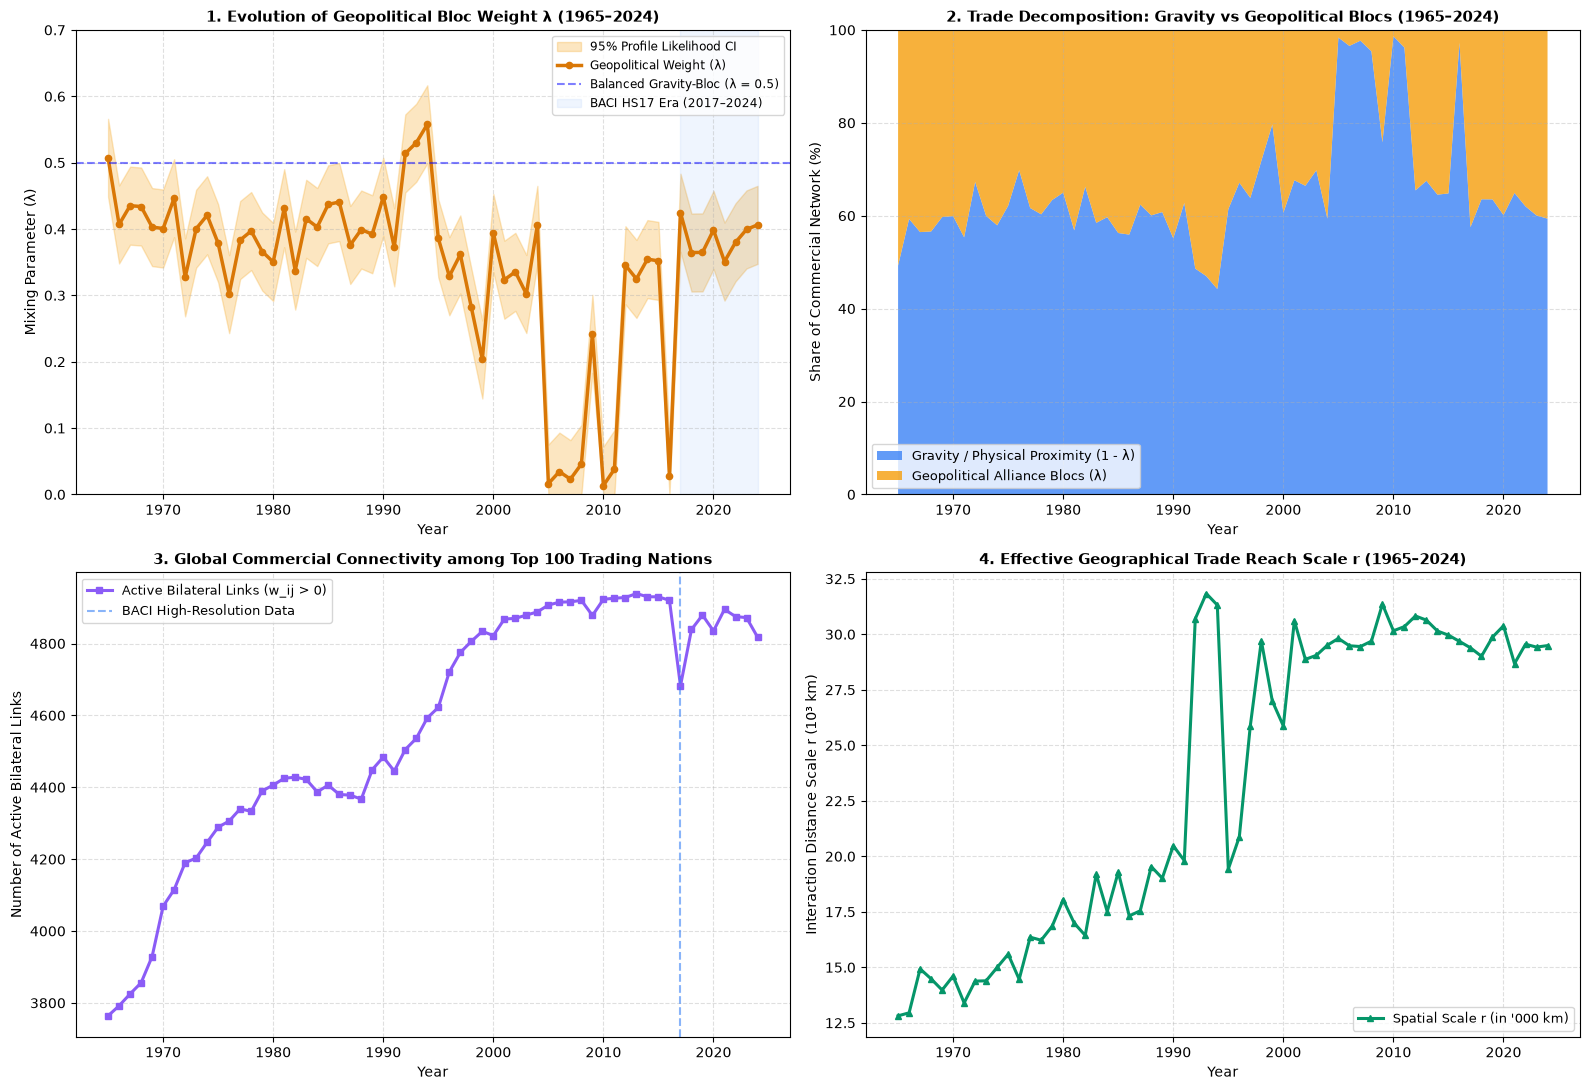

,year,source,lambda,ci_lo,ci_hi,gravity_share,r_km,active_links
45,2010,CEPII Gravity,0.013468,0.000000,0.072268,0.986532,30157.126953,4923
46,2011,CEPII Gravity,0.038092,0.000000,0.096892,0.961908,30347.369141,4926
47,2012,CEPII Gravity,0.345373,0.286573,0.404173,0.654627,30825.210938,4928
48,2013,CEPII Gravity,0.324824,0.266024,0.383624,0.675176,30638.226562,4939
49,2014,CEPII Gravity,0.354612,0.295812,0.413412,0.645388,30147.695312,4930
50,2015,CEPII Gravity,0.351943,0.293143,0.410743,0.648057,29960.734375,4930
51,2016,CEPII Gravity,0.027353,0.000000,0.086153,0.972647,29681.148438,4920
52,2017,BACI HS17,0.424556,0.365756,0.483356,0.575444,29391.021484,4682
53,2018,BACI HS17,0.364554,0.305754,0.423354,0.635446,29010.732422,4839
54,2019,BACI HS17,0.364718,0.305918,0.423518,0.635282,29871.947266,4879


In [9]:
# ======================================================================
# WORLD COMMERCIAL NETWORK: YEAR-BY-YEAR EVOLUTION DASHBOARD (1965–2024)
# Multi-Decade Inference: CEPII Gravity (1965-2016) + BACI HS17 (2017-2024)
# ======================================================================

import os, time, torch, numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

device = torch.device("cpu")
torch.manual_seed(0); np.random.seed(0)

# ----------------------------------------------------------------------
# 1. Setup File Paths and Reference Lookups
# ----------------------------------------------------------------------
gravity_file = "data/World_commercial_network/Gravity_V202211.csv"
coords_file  = "data/World_commercial_network/countries_codes_and_coordinates.csv"
baci_dir     = "data/World_commercial_network/BACI_2017_2024_dataset"

# Coordinates lookup
df_c = pd.read_csv(coords_file)
df_c.columns = [c.strip().replace('"','') for c in df_c.columns]
for col in df_c.columns:
    df_c[col] = df_c[col].astype(str).str.strip().str.replace('"','')
df_c["lat"] = pd.to_numeric(df_c["Latitude (average)"], errors="coerce")
df_c["lon"] = pd.to_numeric(df_c["Longitude (average)"], errors="coerce")
df_c = df_c.dropna(subset=["Alpha-3 code","lat","lon"]).copy()
iso_to_lat  = dict(zip(df_c["Alpha-3 code"], df_c["lat"]))
iso_to_lon  = dict(zip(df_c["Alpha-3 code"], df_c["lon"]))
iso_to_name = dict(zip(df_c["Alpha-3 code"], df_c["Country"]))

# BACI country code mapping
df_cc = pd.read_csv(f"{baci_dir}/country_codes_V202601.csv")
baci_code_to_iso3 = dict(zip(df_cc["country_code"], df_cc["country_iso3"]))

# Model hyperparameters
N_NATIONS   = 100
R_EARTH     = 6371.0
SIGMA_GAUGE = 1.0
d_s         = 2

# All consecutive years from 1965 to 2024 (60 years)
hist_years = list(range(1965, 2017))
baci_years = list(range(2017, 2025))
all_years  = hist_years + baci_years

print(f"Loading data for {len(all_years)} consecutive years (1965–2024)...")

# Fast chunked load for historical years
t_start = time.time()
cols_to_use = ['year','iso3_o','iso3_d','tradeflow_baci','tradeflow_comtrade_o','tradeflow_comtrade_d','tradeflow_imf_o','tradeflow_imf_d']
chunks = []
for chunk in pd.read_csv(gravity_file, usecols=cols_to_use, chunksize=500_000):
    sub = chunk[chunk['year'].isin(hist_years)]
    if not sub.empty:
        chunks.append(sub)
df_hist = pd.concat(chunks, ignore_index=True)
df_hist['val'] = (
    df_hist['tradeflow_baci']
    .fillna(df_hist['tradeflow_comtrade_o'])
    .fillna(df_hist['tradeflow_comtrade_d'])
    .fillna(df_hist['tradeflow_imf_o'])
    .fillna(df_hist['tradeflow_imf_d'])
)
print(f"  → Loaded {len(df_hist)} historical rows in {time.time() - t_start:.2f}s.")

# ----------------------------------------------------------------------
# 2. Year-by-Year Profile Likelihood Inference Loop
# ----------------------------------------------------------------------
results = []
print("\nRunning inference year-by-year from 1965 to 2024...")

for yr in all_years:
    t_yr = time.time()
    if yr in hist_years:
        source_name = "CEPII Gravity"
        df_yr = df_hist[(df_hist['year'] == yr) & (df_hist['val'] > 0) & (df_hist['iso3_o'] != df_hist['iso3_d'])].copy()
        trade_agg = df_yr.groupby(['iso3_o','iso3_d'])['val'].sum().reset_index()
    else:
        source_name = "BACI HS17"
        baci_file = f"{baci_dir}/BACI_HS17_Y{yr}_V202601.csv"
        df_b = pd.read_csv(baci_file, usecols=['i', 'j', 'v'])
        trade_agg = df_b.groupby(['i', 'j'])['v'].sum().reset_index()
        trade_agg['iso3_o'] = trade_agg['i'].map(baci_code_to_iso3)
        trade_agg['iso3_d'] = trade_agg['j'].map(baci_code_to_iso3)
        trade_agg = trade_agg.dropna(subset=['iso3_o', 'iso3_d']).copy()
        trade_agg = trade_agg[(trade_agg['v'] > 0) & (trade_agg['iso3_o'] != trade_agg['iso3_d'])]
        trade_agg.rename(columns={'v': 'val'}, inplace=True)
    
    trade_by_country = (
        trade_agg.groupby('iso3_o')['val'].sum()
        .add(trade_agg.groupby('iso3_d')['val'].sum(), fill_value=0)
    )
    all_c = set(trade_agg['iso3_o']).union(set(trade_agg['iso3_d']))
    valid = all_c.intersection(set(iso_to_lat.keys()))
    top_series = trade_by_country.loc[list(valid)].nlargest(N_NATIONS)
    top_iso = set(top_series.index)
    n_nodes = len(top_iso)
    
    df_top = pd.DataFrame({
        "iso": top_series.index,
        "lat": [iso_to_lat[c] for c in top_series.index],
        "lon": [iso_to_lon[c] for c in top_series.index],
    }).reset_index(drop=True)
    iso_to_idx = {iso: i for i, iso in enumerate(df_top["iso"])}
    
    lat_rad = np.radians(df_top["lat"].values)
    lon_rad = np.radians(df_top["lon"].values)
    x = R_EARTH * np.cos(lat_rad) * np.cos(lon_rad)
    y = R_EARTH * np.cos(lat_rad) * np.sin(lon_rad)
    z = R_EARTH * np.sin(lat_rad)
    X_3d = np.column_stack([x, y, z])
    
    D_phys = cdist(X_3d, X_3d)
    np.fill_diagonal(D_phys, 1e9)
    iu, ju = np.triu_indices(n_nodes, k=1)
    
    trade_top = trade_agg[trade_agg['iso3_o'].isin(top_iso) & trade_agg['iso3_d'].isin(top_iso)]
    W_dir = np.zeros((n_nodes, n_nodes))
    for _, row in trade_top.iterrows():
        W_dir[iso_to_idx[row["iso3_o"]], iso_to_idx[row["iso3_d"]]] += float(row["val"])
    
    W_raw = 0.5 * (W_dir + W_dir.T)
    W = np.log1p(W_raw)
    c_target = float(W.sum(axis=1).mean())
    active_links = int((W > 0).sum() // 2)
    
    r0 = float(2.0 * D_phys.min(axis=1).mean())
    log_r0 = float(np.log(r0))
    
    # PyTorch Tensors
    D_phys_t = torch.tensor(D_phys, dtype=torch.float32, device=device)
    W_obs_u  = torch.tensor(W[iu, ju], dtype=torch.float32, device=device)
    iu_t     = torch.tensor(iu, dtype=torch.long, device=device)
    ju_t     = torch.tensor(ju, dtype=torch.long, device=device)
    eye_mask = 1.0 - torch.eye(n_nodes, device=device)
    
    K_sp0 = np.exp(-D_phys / r0)
    np.fill_diagonal(K_sp0, 0.0)
    s_sp0 = K_sp0.sum(axis=1, keepdims=True) + 1e-12
    W_sp0 = 0.5 * c_target * (K_sp0 / s_sp0 + K_sp0 / s_sp0.T)
    R_init = np.maximum(0.0, W - W_sp0)
    
    U, sv, _ = np.linalg.svd(R_init, full_matrices=False)
    S_init = U[:, :d_s] * np.sqrt(sv[:d_s])
    S_init = (S_init - S_init.mean(axis=0)) / (S_init.std() + 1e-9) * 3.0
    
    logit_lam = torch.tensor(0.0, requires_grad=True, device=device)
    log_r     = torch.tensor(log_r0, requires_grad=True, device=device)
    S_param   = torch.tensor(S_init, requires_grad=True, device=device)
    
    adam_opt = torch.optim.Adam([
        {"params": [logit_lam], "lr": 0.08},
        {"params": [log_r],     "lr": 0.05},
        {"params": [S_param],   "lr": 0.10}
    ])
    for _ in range(35):
        adam_opt.zero_grad()
        lam = torch.sigmoid(logit_lam)
        r   = torch.exp(torch.clamp(log_r, log_r0-3, log_r0+3))
        K_sp = torch.exp(-D_phys_t / r) * eye_mask
        diff = S_param.unsqueeze(1) - S_param.unsqueeze(0)
        D_soc = torch.sqrt((diff**2).sum(-1)+1e-12) + 1e9*torch.eye(n_nodes, device=device)
        K_soc = torch.exp(-D_soc / SIGMA_GAUGE) * eye_mask
        W_raw_t = (1-lam)*K_sp + lam*K_soc
        rs = W_raw_t.sum(dim=1, keepdim=True) + 1e-12
        W_pred = 0.5*c_target*(W_raw_t/rs + W_raw_t/rs.t())
        wu = W_pred[iu_t, ju_t]
        loss = (wu - W_obs_u*torch.log(wu+1e-12)).sum() + 0.5*((log_r-log_r0)/2)**2
        loss.backward(); adam_opt.step()
    
    lbfgs = torch.optim.LBFGS([logit_lam, log_r, S_param], lr=0.5,
                              max_iter=30, history_size=10, line_search_fn="strong_wolfe")
    def closure():
        lbfgs.zero_grad()
        lam = torch.sigmoid(logit_lam)
        r   = torch.exp(torch.clamp(log_r, log_r0-3, log_r0+3))
        K_sp = torch.exp(-D_phys_t / r) * eye_mask
        diff = S_param.unsqueeze(1) - S_param.unsqueeze(0)
        D_soc = torch.sqrt((diff**2).sum(-1)+1e-12) + 1e9*torch.eye(n_nodes, device=device)
        K_soc = torch.exp(-D_soc / SIGMA_GAUGE) * eye_mask
        W_raw_t = (1-lam)*K_sp + lam*K_soc
        rs = W_raw_t.sum(dim=1, keepdim=True) + 1e-12
        W_pred = 0.5*c_target*(W_raw_t/rs + W_raw_t/rs.t())
        wu = W_pred[iu_t, ju_t]
        loss = (wu - W_obs_u*torch.log(wu+1e-12)).sum() + 0.5*((log_r-log_r0)/2)**2
        loss.backward(); return loss
    lbfgs.step(closure)
    
    lam_hat = float(torch.sigmoid(logit_lam).item())
    r_hat   = float(torch.exp(torch.clamp(log_r, log_r0-3, log_r0+3)).item())
    loss_c  = closure().item()
    
    # 95% Profile Likelihood CI
    dl = 0.04; pl = [loss_c]
    for off in [-dl, dl]:
        lt = torch.tensor(float(np.clip(lam_hat+off, 0.01, 0.99)), device=device)
        lr_p = log_r.clone().detach().requires_grad_(True)
        S_p  = S_param.clone().detach().requires_grad_(True)
        opt_p = torch.optim.LBFGS([lr_p, S_p], lr=0.5, max_iter=20, line_search_fn="strong_wolfe")
        def pc():
            opt_p.zero_grad()
            r = torch.exp(torch.clamp(lr_p, log_r0-3, log_r0+3))
            K_sp = torch.exp(-D_phys_t/r)*eye_mask
            diff = S_p.unsqueeze(1)-S_p.unsqueeze(0)
            D_soc = torch.sqrt((diff**2).sum(-1)+1e-12)+1e9*torch.eye(n_nodes, device=device)
            K_soc = torch.exp(-D_soc/SIGMA_GAUGE)*eye_mask
            W_raw_t = (1-lt)*K_sp + lt*K_soc
            rs = W_raw_t.sum(dim=1, keepdim=True)+1e-12
            W_pred = 0.5*c_target*(W_raw_t/rs + W_raw_t/rs.t())
            wu = W_pred[iu_t, ju_t]
            loss = (wu - W_obs_u*torch.log(wu+1e-12)).sum() + 0.5*((lr_p-log_r0)/2)**2
            loss.backward(); return loss
        opt_p.step(pc); pl.append(pc().item())
    
    d2 = (pl[2]-2*pl[0]+pl[1])/(dl**2)
    lam_std = float(np.sqrt(1.0/d2)) if d2 > 1e-3 else 0.03
    ci_lo = float(np.clip(lam_hat-1.96*lam_std, 0, 1))
    ci_hi = float(np.clip(lam_hat+1.96*lam_std, 0, 1))
    
    results.append({
        "year": yr,
        "source": source_name,
        "lambda": lam_hat,
        "ci_lo": ci_lo,
        "ci_hi": ci_hi,
        "gravity_share": 1.0 - lam_hat,
        "r_km": r_hat,
        "active_links": active_links
    })
    if yr % 5 == 0 or yr >= 2017:
        print(f"  → Year {yr:4d}: λ = {lam_hat:.4f} [95% CI: {ci_lo:.4f}, {ci_hi:.4f}] | r = {r_hat:7.1f} km | Links = {active_links} ({time.time() - t_yr:.2f}s)")

df_res = pd.DataFrame(results)
print("\nInference complete for all 60 consecutive years.")

# ----------------------------------------------------------------------
# 3. Clean 4-Panel Visualization (Year-by-Year, lambda in [0.0, 0.7])
# ----------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
years = df_res["year"].values
lams  = df_res["lambda"].values
ci_l  = df_res["ci_lo"].values
ci_h  = df_res["ci_hi"].values

# Panel 1: Lambda vs Year (Clean, y in [0.0, 0.7])
ax1 = axes[0, 0]
ax1.fill_between(years, ci_l, ci_h, color="#f59e0b", alpha=0.25, label="95% Profile Likelihood CI")
ax1.plot(years, lams, marker="o", color="#d97706", lw=2.5, markersize=4.5, label="Geopolitical Weight (λ)")
ax1.axhline(0.5, color="blue", ls="--", alpha=0.5, label="Balanced Gravity-Bloc (λ = 0.5)")
ax1.axvspan(2017, 2024, color="#3b82f6", alpha=0.08, label="BACI HS17 Era (2017–2024)")
ax1.set_xlabel("Year", fontsize=10)
ax1.set_ylabel("Mixing Parameter (λ)", fontsize=10)
ax1.set_title("1. Evolution of Geopolitical Bloc Weight λ (1965–2024)", fontweight="bold", fontsize=11)
ax1.set_ylim(0.0, 0.7)
ax1.grid(True, ls="--", alpha=0.4)
ax1.legend(loc="upper right", fontsize=8.5)

# Panel 2: Stacked Decomposition Share (%)
ax2 = axes[0, 1]
ax2.stackplot(years, df_res["gravity_share"]*100, df_res["lambda"]*100,
              labels=["Gravity / Physical Proximity (1 - λ)", "Geopolitical Alliance Blocs (λ)"],
              colors=["#3b82f6", "#f59e0b"], alpha=0.8)
ax2.set_xlabel("Year", fontsize=10)
ax2.set_ylabel("Share of Commercial Network (%)", fontsize=10)
ax2.set_title("2. Trade Decomposition: Gravity vs Geopolitical Blocs (1965–2024)", fontweight="bold", fontsize=11)
ax2.set_ylim(0, 100)
ax2.grid(True, ls="--", alpha=0.4)
ax2.legend(loc="lower left", fontsize=9)

# Panel 3: Active Bilateral Links (Network Density)
ax3 = axes[1, 0]
ax3.plot(years, df_res["active_links"], marker="s", color="#8b5cf6", lw=2.2, markersize=4.0, label="Active Bilateral Links (w_ij > 0)")
ax3.axvline(2017, color="#3b82f6", ls="--", alpha=0.6, label="BACI High-Resolution Data")
ax3.set_xlabel("Year", fontsize=10)
ax3.set_ylabel("Number of Active Bilateral Links", fontsize=10)
ax3.set_title("3. Global Commercial Connectivity among Top 100 Trading Nations", fontweight="bold", fontsize=11)
ax3.grid(True, ls="--", alpha=0.4)
ax3.legend(loc="upper left", fontsize=9)

# Panel 4: Geographical Reach (r)
ax4 = axes[1, 1]
ax4.plot(years, df_res["r_km"] / 1000.0, marker="^", color="#059669", lw=2.2, markersize=4.0, label="Spatial Scale r (in '000 km)")
ax4.set_xlabel("Year", fontsize=10)
ax4.set_ylabel("Interaction Distance Scale r (10³ km)", fontsize=10)
ax4.set_title("4. Effective Geographical Trade Reach Scale r (1965–2024)", fontweight="bold", fontsize=11)
ax4.grid(True, ls="--", alpha=0.4)
ax4.legend(loc="lower right", fontsize=9)

plt.tight_layout()
plt.show()

# Summary table display
display(df_res[["year", "source", "lambda", "ci_lo", "ci_hi", "gravity_share", "r_km", "active_links"]].tail(15))
